In [82]:
try:
    import os,re
    import csv
    import pandas as pd
    import numpy as np
    import warnings
    import seaborn as sns
    import matplotlib.pyplot as plt
    import fastf1
    import fastf1.plotting
    warnings.filterwarnings("ignore")
    from pathlib import Path
    from sklearn.linear_model import LogisticRegression
    from sklearn.feature_selection import RFE
    from sklearn.impute import SimpleImputer, KNNImputer
    from sklearn.preprocessing import StandardScaler, label_binarize, MinMaxScaler
    from sklearn.pipeline import Pipeline
    from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split, GroupShuffleSplit
    from sklearn.linear_model import LogisticRegression
    from sklearn.naive_bayes import GaussianNB, MultinomialNB
    from sklearn.feature_selection import RFECV
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score, auc, classification_report, precision_recall_curve
    from sklearn import metrics
    import statsmodels.formula.api as sm
    from typing import List, Optional
    import math
    import shutil
    from sklearn.pipeline import Pipeline
    import ipywidgets as widgets
    from IPython.display import display, clear_output, HTML
    import plotly.graph_objects as go
    import plotly.express as px
    print('Imported all packages successfully!')
except Exception as e:
    print(f"Exception importing the given list of packakges: {e}")
    print("Installing the following packages....")
    %pip install -r "requirements.txt"
    warnings.filterwarnings("ignore")
    print("Installation Successfull!")

Imported all packages successfully!


<h4>
<b>
Let's Build a Machine Learning Model that Estimates the probability of each driver.
<hr/>
finishing on the podium in a Formula 1 Grand Prix. (Round 1 Austrailia 🐨) <br/>
<hr/>
🎯 Target Prediction -> Podium
<hr/>
Phase I: Before Saturday Qualifying 
</b>
</h4>

<h4><b>✅ Allowed Pre-Quali Features !!!</b></h4>
<div>
    <h4>1. Driver Form:</h4>
    <ul>
        <li><b>Last N race finishes</b></li>
        <li><b>Podium count (recent)</b></li>
        <li><b>Average finishing position</b></li>
        <li><b>Points in last N races</b></li>
        <li><b>DNF rate</b></li>
        <li><b>Teammate comparison</b><br/>
        <ul>
            <li><b>teammate_points</b></li>
            <li><b>teammate_podium</b></li>
            <li><b>teammate_finish_delta</b></li>
            <li><b>teammate_points_delta</b></li>
            <li><b>avg_teammate_finish_delta_last_n</b></li>
            <li><b>avg_teammate_points_delta_last_n</b></li>
        </ul>
        </li>
    </ul>
</div>
<hr/>
<div>
    <h4>2. Team Performance:</h4>
    <ul>
        <li><b>Constructor standings</b></li>
        <li><b>Average team finish</b></li>
        <li><b>Team reliability</b></li>
        <li><b>Pace ranking (season-to-date proxy)</b></li>
        <li><b>Historical team performance</b></li>
    </ul>
</div>
<hr/>
<div>
    <h4>3. Track / Circuit Context:</h4>
    <ul>
        <li><b>Circuit type (street / permanent)</b></li>
        <li><b>Downforce requirement</b></li>
        <li><b>Historical driver performance at this track</b></li>
        <li><b>Historical team performance at this track</b></li>
    </ul>
</div>
<hr/>
<div>
    <h4>4. Practice Sessions (FP1, FP2, FP3):</h4>
    <ul>
        <li><b>Best lap time</b></li>
        <li><b>Average lap time</b></li>
        <li><b>Long-run pace proxy</b></li>
        <li><b>Stint consistency</b></li>
        <li><b>Session ranking</b></li>
        <li><b>Improvement across sessions</b></li>
    </ul>
</div>
<hr/>
<div>
    <h4>5. Weekend Context:</h4>
    <ul>
        <li><b>Weather forecast</b></li>
        <li><b>Track temperature</b></li>
        <li><b>Sprint weekend indicator</b></li>
        <li><b>Penalties known before quali</b></li>
    </ul>
</div>
<hr/>

In [2]:
# Lets load and build the Driver Form Features
def load_driver_form(results_df: pd.DataFrame, n_races: int=10) -> pd.DataFrame:
    """
    Step1: Build Driver Features from historical Race Data.
    We will be using these column names throughout
    Columns:
        - Season
        - Round
        - Driver/ DriverCode
        - Constructor
        - Position
        - Points
        - Status

    Returns:
        DataFrame with one row per driver per race and lag/rolling form features.
    """
    try:
        df = results_df.copy()
        # We will be using the above column names, so we need map the ones from fastf1 to these
        rename = {}
        if "Season" not in df.columns and "year" in df.columns:
            rename["year"] = "Season"
        if "Round" not in df.columns and "round" in df.columns:
            rename["round"] = "Round"
        if "Driver" not in df.columns and "Abbreviation" in df.columns:
            rename["Abbreviation"] = "Driver"
        if "Driver" not in df.columns and "DriverCode" in df.columns:
            rename["DriverCode"] = "Driver"
        if "Driver" not in df.columns and "FullName" in df.columns:
            rename["FullName"] = "Driver"
        if "Team" not in df.columns and "TeamName" in df.columns:
            rename["TeamName"] = "Team"
        if "Team" not in df.columns and "Constructor" in df.columns:
            rename["Constructor"] = "Team"
        if "Status" not in df.columns and "ResultStatus" in df.columns:
            rename["ResultStatus"] = "Status"

        df = df.rename(columns=rename)
        required_cols = ["Season", "Round", "Driver", "Team", "Position", "Points"]
        missing = [c for c in required_cols if c not in df.columns]
        if missing:
            raise ValueError(f"Missing required columns: {missing}")

        # Clean the Columns
        df["Position"] = pd.to_numeric(df["Position"], errors="coerce")
        df["Points"] = pd.to_numeric(df["Points"], errors="coerce").fillna(0)
        
        # Retirements/Non-Finisheres/Non-Participants (especially for checo and bottas lol)
        if "Status" in df.columns:
            df["DNF"] = (~df["Status"].astype(str).str.contains("Finished", case=False)).astype(int)
        else:
            df["DNF"] = df["Position"].isna().astype(int)

        # Podium Flag for the historical Race Result --- This will one of the strongest features later as we see
        df["Podium"] = (df["Position"] <= 3).astype(int)
        
        # Sort in time order
        df = df.sort_values(["Driver", "Season", "Round"]).reset_index(drop=True)
        print("Loaded Driver's Past Form")
        
        # Create last N-races Features, group them and average their results in the df
        group = df.groupby("Driver", group_keys=False)
        for i in range(n_races + 1):
            df[f"finish_lag_{i}"] = group["Position"].shift(i)
            df[f"points_lag_{i}"] = group["Points"].shift(i)
            df[f"podium_lag_{i}"] = group["Podium"].shift(i)
            df[f"dnf_lag_{i}"] = group["DNF"].shift(i)

        df["avg_finish_in_last_n_races"] = (
            group["Position"]
            .apply(lambda s: s.shift(1).rolling(n_races, min_periods=1).mean())
            .reset_index(level=0, drop=True)
        )

        df["avg_points_in_last_n_races"] = (
            group["Points"]
            .apply(lambda s: s.shift(1).rolling(n_races, min_periods=1).mean())
            .reset_index(level=0, drop=True)
        )

        df["podium_count_in_last_n_races"] = (
            group["Podium"]
            .apply(lambda s: s.shift(1).rolling(n_races, min_periods=1).sum())
            .reset_index(level=0, drop=True)
        )

        df["dnf_rate_in_last_n_races"] = (
            group["Podium"]
            .apply(lambda s: s.shift(1).rolling(n_races, min_periods=1).mean())
            .reset_index(level=0, drop=True)
        )
        print("Loaded Driver's Last N-Races Performance")

        # Teammate comparison Features [Head to Head]
        df["teammate_finish"] = np.nan
        df["teammate_points"] = np.nan
        df["teammate_podium"] = np.nan

        race_team_groups = df.groupby(["Season", "Round", "Team"], dropna=False)
        for (_, _, _), idx in race_team_groups.groups.items():
            race_team_rows = df.loc[idx]
            if len(race_team_rows) < 2:
                continue

            positions = race_team_rows["Position"].values
            points = race_team_rows["Points"].values
            podiums = race_team_rows["Podium"].values

            # For each driver, teammate is the other row in the same team
            for pos_idx, row_idx in enumerate(race_team_rows.index):
                teammate_pos = positions[1 - pos_idx] if len(positions) >= 2 else np.nan
                teammate_pts = points[1 - pos_idx] if len(points) >= 2 else np.nan
                teammate_pod = podiums[1 - pos_idx] if len(podiums) >= 2 else np.nan

                df.loc[row_idx, "teammate_finish"] = teammate_pos
                df.loc[row_idx, "teammate_points"] = teammate_pts
                df.loc[row_idx, "teammate_podium"] = teammate_pod

        df["teammate_finish_delta"] = df["teammate_finish"] - df["Position"]
        df["teammate_points_delta"] = df["Points"] - df["teammate_points"]

        # Rolling teammate comparison based on past races only
        df["avg_teammate_finish_delta_last_n"] = (
            group["teammate_finish_delta"]
            .apply(lambda s: s.shift(1).rolling(n_races, min_periods=1).mean())
            .reset_index(level=0, drop=True)
        )

        df["avg_teammate_points_delta_last_n"] = (
            group["teammate_points_delta"]
            .apply(lambda s: s.shift(1).rolling(n_races, min_periods=1).mean())
            .reset_index(level=0, drop=True)
        )

        print("Loaded Teammate's Head to Head Comparison")

        # Final Cleanup
        feature_cols = [
            "Season", "Round", "Driver", "Team", "Position", "Points", "Status" if "Status" in df.columns else None,
            "Podium", "DNF",
            *[f"finish_lag_{i}" for i in range(1, n_races + 1)],
            *[f"points_lag_{i}" for i in range(1, n_races + 1)],
            *[f"podium_lag_{i}" for i in range(1, n_races + 1)],
            *[f"dnf_lag_{i}" for i in range(1, n_races + 1)],
            "avg_finish_last_n",
            "podium_count_last_n",
            "avg_points_last_n",
            "dnf_rate_last_n",
            "teammate_finish",
            "teammate_points",
            "teammate_podium",
            "teammate_finish_delta",
            "teammate_points_delta",
            "avg_teammate_finish_delta_last_n",
            "avg_teammate_points_delta_last_n",
        ]
        feature_cols = [c for c in feature_cols if c is not None and c in df.columns]
        print("Driver Form features Ready!")
        return df[feature_cols].copy()
    except Exception as e:
        print(f"Error Loading Driver Form Features: \n{e}")
        return pd.DataFrame

In [3]:
"""
Lets build a helper function to load previous race 
!!!! IMP: Always cache fastf1, when using it for large data loading ops !!!
"""
CACHE_DIR = '../data/cache'
if os.path.isdir(CACHE_DIR):
    print("CACHE DIR Already Exists")
else:
    os.mkdir(CACHE_DIR)
    
fastf1.Cache.enable_cache(CACHE_DIR)
def help_load_race_data(seasons: list) -> pd.DataFrame:
    all_res = []
    for y in seasons:
        schedule = fastf1.get_event_schedule(y)
        
        for _, event in schedule.iterrows():
            try:
                session = fastf1.get_session(y, event["RoundNumber"], "R")
                session.load()

                results = session.results.copy()

                results["Season"] = y
                results["Round"] = event["RoundNumber"]
                results["EventName"] = event["EventName"]

                results = results.rename(columns={
                    "Abbreviation": "Driver",
                    "TeamName": "Team",
                    "Position": "Position",
                    "Points": "Points",
                    "Status": "Status"
                })

                results = results[[
                    "Season",
                    "Round",
                    "EventName",
                    "Driver",
                    "Team",
                    "Position",
                    "Points",
                    "Status"
                ]]

                all_res.append(results)

                print(f"Loaded {y} Round {event['RoundNumber']}")
            except Exception as e:
                print(f"Skipping {y} Round {event['RoundNumber']} because: {e}")
    return pd.concat(all_res, ignore_index=True)

CACHE DIR Already Exists


In [ ]:
# Let's Build the base Dataset
seasons = [2024, 2025]
results_df = help_load_race_data(seasons)
results_df.head(3)

In [ ]:
driver_form_df = load_driver_form(results_df, n_races=15)
driver_form_df.head(5)

In [ ]:
extract_cols = driver_form_df.columns[:9].tolist() + driver_form_df.columns[70:].tolist()
extract_cols

In [ ]:
driver_form_df_extract = driver_form_df[extract_cols].copy()
driver_form_df_extract.shape

In [4]:
def load_team_data(seasons: list, n_races: int=15) -> pd.DataFrame:
    """
    Step 2 in Data Extraction
    
    Get the following Team Performance Data from the last seasons

    constructor standings
    
    average team finish
    
    team reliability
    
    pace ranking (season-to-date proxy)
    
    historical team performance
    """
    res = []
    for y in seasons:
        schedule = fastf1.get_event_schedule(y)
        for _, event in schedule.iterrows():
            round_no = int(event["RoundNumber"])
            try:
                session = fastf1.get_session(y, event["RoundNumber"], "R")
                session.load()
                
                results = session.results.copy()

                if "TeamName" in results.columns:
                    results["Team"] = results["TeamName"]
                elif "ConstructorName" in results.columns:
                    results["Team"] = results["ConstructorName"]
                else:
                    raise ValueError("No TeamName/ConstructorName column found in FastF1 results.")

                results["Season"] = y
                results["Round"] = round_no
                results["EventName"] = event["EventName"]

                results["Position"] = pd.to_numeric(results["Position"], errors="coerce")
                results["Points"] = pd.to_numeric(results["Points"], errors="coerce").fillna(0)

                finished_pattern = r"Finished|Lapped|\+\d+\sLap[s]?|Classified"
                results["Finished"] = (
                    results["Status"].astype(str).str.contains(
                        finished_pattern,
                        case=False,
                        na=False,
                        regex=True
                    )
                ).astype(int)

                results["DNF"] = (1 - results["Finished"]).astype(int)
                results["Podium"] = (results["Position"] <= 3).astype(int)

                team_race = results.groupby(
                    ["Season", "Round", "EventName", "Team"],
                    as_index=False
                ).agg(
                    team_points=("Points", "sum"),
                    avg_team_finish=("Position", "mean"),
                    best_team_finish=("Position", "min"),
                    team_podiums=("Podium", "sum"),
                    team_dnfs=("DNF", "sum"),
                    team_finishers=("Finished", "sum"),
                    drivers_count=("Team", "size")
                )

                res.append(team_race)
                print(f"Loaded {y} R{round_no}: {event['EventName']}")

            except Exception as e:
                print(f"Skipping {y} R{round_no}: {e}")

    if not res:
        return pd.DataFrame()

    team_df = pd.concat(res, ignore_index=True)
    team_df = team_df.sort_values(["Season", "Team", "Round"]).reset_index(drop=True)

    g = team_df.groupby(["Season", "Team"], group_keys=False)

    team_df["constructor_points_prev"] = g["team_points"].apply(
        lambda s: s.shift(1).cumsum()
    ).reset_index(level=0, drop=True)

    team_df["avg_finish_to_date_prev"] = g["avg_team_finish"].apply(
        lambda s: s.shift(1).expanding(min_periods=1).mean()
    ).reset_index(level=0, drop=True)

    team_df["avg_points_to_date_prev"] = g["team_points"].apply(
        lambda s: s.shift(1).expanding(min_periods=1).mean()
    ).reset_index(level=0, drop=True)

    team_df["dnf_rate_to_date_prev"] = g["team_dnfs"].apply(
        lambda s: s.shift(1).expanding(min_periods=1).mean()
    ).reset_index(level=0, drop=True)

    team_df["reliability_to_date_prev"] = 1 - team_df["dnf_rate_to_date_prev"]

    team_df[f"avg_team_finish_last_{n_races}"] = g["avg_team_finish"].apply(
        lambda s: s.shift(1).rolling(n_races, min_periods=1).mean()
    ).reset_index(level=0, drop=True)

    team_df[f"team_points_last_{n_races}"] = g["team_points"].apply(
        lambda s: s.shift(1).rolling(n_races, min_periods=1).mean()
    ).reset_index(level=0, drop=True)

    team_df[f"team_dnf_rate_last_{n_races}"] = g["team_dnfs"].apply(
        lambda s: s.shift(1).rolling(n_races, min_periods=1).mean()
    ).reset_index(level=0, drop=True)

    # Historical team performance at this event name
    eg = team_df.groupby(["Team", "EventName"], group_keys=False)

    team_df["historical_event_avg_finish_prev"] = eg["avg_team_finish"].apply(
        lambda s: s.shift(1).expanding(min_periods=1).mean()
    ).reset_index(level=0, drop=True)

    team_df["historical_event_avg_points_prev"] = eg["team_points"].apply(
        lambda s: s.shift(1).expanding(min_periods=1).mean()
    ).reset_index(level=0, drop=True)

    team_df["historical_event_podium_rate_prev"] = eg["team_podiums"].apply(
        lambda s: s.shift(1).expanding(min_periods=1).mean()
    ).reset_index(level=0, drop=True)

    # Constructor standings proxy and pace rank for each race
    team_df["constructor_points_prev"] = team_df["constructor_points_prev"].fillna(0)

    team_df["constructor_standing_prev"] = team_df.groupby(["Season", "Round"])["constructor_points_prev"].rank(
        ascending=False,
        method="min"
    )

    team_df["pace_rank_prev"] = team_df.groupby(["Season", "Round"])["avg_finish_to_date_prev"].rank(
        ascending=True,
        method="min"
    )

    return team_df
                

In [ ]:
"""Rememeber to cache this execution in future"""
team_performance_df = load_team_data([2024, 2025], n_races=15)

In [ ]:
team_performance_df.head(3)

In [ ]:
driver_team_df_merge = driver_form_df_extract.merge(
    team_performance_df,
    on=["Season", "Round", "Team"],
    how="left"
)

driver_team_df_merge.head(3)

In [25]:
driver_team_df_merge.columns

Index(['Season', 'Round', 'Driver', 'Team', 'Position', 'Points', 'Status',
       'Podium', 'DNF', 'teammate_points', 'teammate_podium',
       'teammate_finish_delta', 'teammate_points_delta',
       'avg_teammate_finish_delta_last_n', 'avg_teammate_points_delta_last_n',
       'EventName', 'team_points', 'avg_team_finish', 'best_team_finish',
       'team_podiums', 'team_dnfs', 'team_finishers', 'drivers_count',
       'constructor_points_prev', 'avg_finish_to_date_prev',
       'avg_points_to_date_prev', 'dnf_rate_to_date_prev',
       'reliability_to_date_prev', 'avg_team_finish_last_15',
       'team_points_last_15', 'team_dnf_rate_last_15',
       'historical_event_avg_finish_prev', 'historical_event_avg_points_prev',
       'historical_event_podium_rate_prev', 'constructor_standing_prev',
       'pace_rank_prev'],
      dtype='object')

In [16]:
driver_team_df_merge.describe()

,Season,Round,Position,Points,Podium,DNF,teammate_points,teammate_podium,teammate_finish_delta,teammate_points_delta,...,dnf_rate_to_date_prev,reliability_to_date_prev,avg_team_finish_last_15,team_points_last_15,team_dnf_rate_last_15,historical_event_avg_finish_prev,historical_event_avg_points_prev,historical_event_podium_rate_prev,constructor_standing_prev,pace_rank_prev
count,658.000000,658.000000,658.000000,658.000000,658.000000,658.000000,656.000000,656.000000,656.000000,656.000000,...,618.000000,618.000000,618.000000,618.000000,618.000000,161.000000,161.000000,161.000000,658.000000,618.000000
mean,2024.272036,10.468085,10.471125,5.094225,0.150456,0.364742,5.106707,0.150915,0.000000,0.000000,...,0.230512,0.769488,10.458027,10.195310,0.231385,10.099379,11.167702,0.335404,5.098784,5.456311
std,0.445347,6.924888,5.755541,7.218503,0.357790,0.481724,7.225752,0.358239,5.841154,7.244477,...,0.208273,0.208273,4.242194,11.336357,0.209817,5.327353,13.568915,0.611802,2.862283,2.875403
min,2024.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-19.000000,-26.000000,...,0.000000,0.000000,1.500000,0.000000,0.000000,1.500000,0.000000,0.000000,1.000000,1.000000
25%,2024.000000,5.000000,5.250000,0.000000,0.000000,0.000000,0.000000,0.000000,-3.000000,-2.000000,...,0.085227,0.694231,6.200000,0.883333,0.066667,5.000000,0.000000,0.000000,3.000000,3.000000
50%,2024.000000,9.000000,10.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,0.210526,0.789474,11.500000,4.000000,0.200000,11.000000,3.000000,0.000000,5.000000,5.000000
75%,2025.000000,16.000000,15.000000,9.750000,0.000000,1.000000,10.000000,0.000000,3.000000,2.000000,...,0.305769,0.914773,14.000000,19.333333,0.333333,14.500000,22.000000,1.000000,8.000000,8.000000
max,2025.000000,24.000000,20.000000,26.000000,1.000000,1.000000,26.000000,1.000000,19.000000,26.000000,...,1.000000,1.000000,17.500000,44.000000,1.000000,19.500000,44.000000,2.000000,10.000000,10.000000


In [5]:
"""
Step 3 in data extraction -> Track/Circuit Context:

Circuit type (street / permanent)

Downforce requirement

Historical driver performance at this track

Historical team performance at this track

Expected Input: driver_team_df_merge as it is
Expected Output: Merged df with track Context
"""
# I will pass the driver_team_df_merge df into this
def extract_track_context(df: pd.DataFrame, 
                          track_meta_df: Optional[pd.DataFrame] = None,
                          event_key_col: str = "EventName",
                         ) -> pd.DataFrame:
    try:
        out = df.copy()

        required_cols = ["Season", "Round", "Driver", "Team", "Position", "Points", "Podium", event_key_col]
        missing = [c for c in required_cols if c not in out.columns]
        if missing:
            raise ValueError(f"Missing required columns in input df: {missing}")

        out["Position"] = pd.to_numeric(out["Position"], errors="coerce")
        out["Points"] = pd.to_numeric(out["Points"], errors="coerce").fillna(0)

        out = out.sort_values(["Season", "Round", "Driver"]).reset_index(drop=True)


        if track_meta_df is not None:
            meta = track_meta_df.copy()

            if event_key_col not in meta.columns:
                raise ValueError(f"track_meta_df must contain '{event_key_col}'")

            expected_meta_cols = [event_key_col, "CircuitType", "DownforceRequirement"]
            missing_meta = [c for c in expected_meta_cols if c not in meta.columns]
            if missing_meta:
                raise ValueError(f"track_meta_df is missing columns: {missing_meta}")

            meta = meta[expected_meta_cols].drop_duplicates(subset=[event_key_col])
            out = out.merge(meta, on=event_key_col, how="left")

        else:
            out["CircuitType"] = np.nan
            out["DownforceRequirement"] = np.nan

        driver_track_grp = out.groupby(["Driver", event_key_col], group_keys=False)

        out["track_driver_starts_prev"] = driver_track_grp.cumcount()

        out["track_driver_avg_finish_prev"] = (
            driver_track_grp["Position"]
            .apply(lambda s: s.shift(1).expanding(min_periods=1).mean())
            .reset_index(level=0, drop=True)
        )

        out["track_driver_avg_points_prev"] = (
            driver_track_grp["Points"]
            .apply(lambda s: s.shift(1).expanding(min_periods=1).mean())
            .reset_index(level=0, drop=True)
        )

        out["track_driver_podium_rate_prev"] = (
            driver_track_grp["Podium"]
            .apply(lambda s: s.shift(1).expanding(min_periods=1).mean())
            .reset_index(level=0, drop=True)
        )


        team_track_grp = out.groupby(["Team", event_key_col], group_keys=False)

        out["track_team_starts_prev"] = team_track_grp.cumcount()

        out["track_team_avg_finish_prev"] = (
            team_track_grp["Position"]
            .apply(lambda s: s.shift(1).expanding(min_periods=1).mean())
            .reset_index(level=0, drop=True)
        )

        out["track_team_avg_points_prev"] = (
            team_track_grp["Points"]
            .apply(lambda s: s.shift(1).expanding(min_periods=1).mean())
            .reset_index(level=0, drop=True)
        )

        out["track_team_podium_rate_prev"] = (
            team_track_grp["Podium"]
            .apply(lambda s: s.shift(1).expanding(min_periods=1).mean())
            .reset_index(level=0, drop=True)
        )

        out["track_driver_is_home_event"] = 0
        out["track_context_available"] = (
            out["CircuitType"].notna().astype(int)
            if "CircuitType" in out.columns
            else 0
        )

        return out

    except Exception as e:
        print(f"Error extracting track context:\n{e}")
        raise

In [6]:
track_meta_df = pd.DataFrame([
    {"EventName": "Bahrain Grand Prix", "CircuitType": "Permanent", "DownforceRequirement": "Medium"},
    {"EventName": "Saudi Arabian Grand Prix", "CircuitType": "Street", "DownforceRequirement": "Low"},
    {"EventName": "Australian Grand Prix", "CircuitType": "Street", "DownforceRequirement": "Medium"},
    {"EventName": "Japanese Grand Prix", "CircuitType": "Permanent", "DownforceRequirement": "High"},
    {"EventName": "Chinese Grand Prix", "CircuitType": "Permanent", "DownforceRequirement": "Medium"},
    {"EventName": "Miami Grand Prix", "CircuitType": "Street", "DownforceRequirement": "Medium"},
    {"EventName": "Emilia Romagna Grand Prix", "CircuitType": "Permanent", "DownforceRequirement": "High"}, # (Ends 2025)
    {"EventName": "Monaco Grand Prix", "CircuitType": "Street", "DownforceRequirement": "Maximum"},
    {"EventName": "Canadian Grand Prix", "CircuitType": "Street", "DownforceRequirement": "Low"},
    {"EventName": "Spanish Grand Prix (Barcelona)", "CircuitType": "Permanent", "DownforceRequirement": "High"},
    {"EventName": "Austrian Grand Prix", "CircuitType": "Permanent", "DownforceRequirement": "Medium"},
    {"EventName": "British Grand Prix", "CircuitType": "Permanent", "DownforceRequirement": "High"},
    {"EventName": "Hungarian Grand Prix", "CircuitType": "Permanent", "DownforceRequirement": "High"},
    {"EventName": "Belgian Grand Prix", "CircuitType": "Permanent", "DownforceRequirement": "Medium"},
    {"EventName": "Dutch Grand Prix", "CircuitType": "Permanent", "DownforceRequirement": "High"},
    {"EventName": "Italian Grand Prix", "CircuitType": "Permanent", "DownforceRequirement": "Low"},
    {"EventName": "Azerbaijan Grand Prix", "CircuitType": "Street", "DownforceRequirement": "Low"},
    {"EventName": "Singapore Grand Prix", "CircuitType": "Street", "DownforceRequirement": "Maximum"},
    {"EventName": "United States Grand Prix", "CircuitType": "Permanent", "DownforceRequirement": "Medium"},
    {"EventName": "Mexico City Grand Prix", "CircuitType": "Permanent", "DownforceRequirement": "High"},
    {"EventName": "São Paulo Grand Prix", "CircuitType": "Permanent", "DownforceRequirement": "Medium"},
    {"EventName": "Las Vegas Grand Prix", "CircuitType": "Street", "DownforceRequirement": "Low"},
    {"EventName": "Qatar Grand Prix", "CircuitType": "Permanent", "DownforceRequirement": "High"},
    {"EventName": "Abu Dhabi Grand Prix", "CircuitType": "Permanent", "DownforceRequirement": "Medium"},
    {"EventName": "Spanish Grand Prix (Madrid)", "CircuitType": "Street", "DownforceRequirement": "Medium"} # (Starts 2026)
])

In [35]:
track_context_df = extract_track_context(
    driver_team_df_merge,
    track_meta_df = track_meta_df
)

In [38]:
track_context_df.query('Driver == "VER"').head(3)

,Season,Round,Driver,Team,Position,Points,Status,Podium,DNF,teammate_points,...,track_driver_starts_prev,track_driver_avg_finish_prev,track_driver_avg_points_prev,track_driver_podium_rate_prev,track_team_starts_prev,track_team_avg_finish_prev,track_team_avg_points_prev,track_team_podium_rate_prev,track_driver_is_home_event,track_context_available
18,2024,1,VER,Red Bull Racing,1.0,26.0,Finished,1,0,18.0,...,0,NaN,NaN,NaN,1,2.0,18.0,1.0,0,1
38,2024,2,VER,Red Bull Racing,1.0,25.0,Finished,1,0,18.0,...,0,NaN,NaN,NaN,1,2.0,18.0,1.0,0,1
57,2024,3,VER,Red Bull Racing,19.0,0.0,Retired,0,1,10.0,...,0,NaN,NaN,NaN,1,5.0,10.0,0.0,0,1


In [7]:
"""
Lets extract 4 & 5 in one step and merge them with exisintg df,

Practice Sessions (FP1, FP2, FP3):

    Best lap time
    
    Average lap time
    
    Long-run pace proxy
    
    Stint consistency
    
    Session ranking
    
    Improvement across sessions

5. Weekend Context:
    Weather forecast
    
    Track temperature
    
    Sprint weekend indicator
    
    Penalties known before quali
"""
def load_practice_data(seasons: List[int], n_races: int=15, practice_sessions: Optional[List[str]]=None) -> pd.DataFrame:
    if practice_sessions is None:
        practice_sessions = ['FP1', 'FP2', 'FP3']
    all_rows = []
    weather_rows = []
    penalty_rows = []
    try:
        for season in seasons:
            schedule = fastf1.get_event_schedule(season)

            sprint_rounds = set()
            if "EventFormat" in schedule.columns:
                sprint_rounds = set(
                    schedule.loc[
                        schedule["EventFormat"].astype(str).str.contains("sprint", case=False, na=False),
                        "RoundNumber"
                    ].dropna().astype(int).tolist()
                )
            else:
                # scan schedule text for "sprint"
                text_cols = [c for c in schedule.columns if schedule[c].dtype == "object"]
                if text_cols:
                    sprint_mask = False
                    for c in text_cols:
                        sprint_mask = sprint_mask | schedule[c].astype(str).str.contains("sprint", case=False, na=False)
                    sprint_rounds = set(schedule.loc[sprint_mask, "RoundNumber"].dropna().astype(int).tolist())

            for _, event in schedule.iterrows():
                round_no = int(event["RoundNumber"])

                for session_name in practice_sessions:
                    try:
                        print(f"Loading {season} R{round_no} {session_name}")
                        session = fastf1.get_session(season, round_no, session_name)

                        session.load(laps=True, telemetry=False, weather=True, messages=True)

                        laps = session.laps.copy()
                        if laps.empty:
                            continue

                        if "Driver" not in laps.columns:
                            raise ValueError(f"'Driver' column missing in {season} R{round_no} {session_name}")

                        laps["LapTime_sec"] = pd.to_timedelta(laps["LapTime"], errors="coerce").dt.total_seconds()

                        if "IsAccurate" in laps.columns:
                            laps = laps[laps["IsAccurate"].fillna(True)]

                        laps = laps[laps["LapTime_sec"].notna()].copy()
                        if laps.empty:
                            continue

                        session_rows = []

                        for drv, d in laps.groupby("Driver"):
                            d = d.sort_values("LapNumber") if "LapNumber" in d.columns else d.copy()

                            best_lap_sec = d["LapTime_sec"].min()
                            avg_lap_sec = d["LapTime_sec"].mean()


                            if "Stint" in d.columns:
                                stint_stats = (
                                    d.groupby("Stint")["LapTime_sec"]
                                    .agg(stint_laps="count", stint_mean="mean", stint_std="std")
                                    .reset_index()
                                )

                                valid_stints = stint_stats[stint_stats["stint_laps"] >= 3].copy()
                                if valid_stints.empty:
                                    valid_stints = stint_stats.copy()

                                valid_stints = valid_stints.sort_values(
                                    by=["stint_laps", "stint_mean"],
                                    ascending=[False, True]
                                )

                                chosen = valid_stints.iloc[0]
                                long_run_pace_sec = chosen["stint_mean"]
                                stint_consistency_sec = chosen["stint_std"]
                            else:
                                long_run_pace_sec = avg_lap_sec
                                stint_consistency_sec = d["LapTime_sec"].std()

                            session_rows.append({
                                "Season": season,
                                "Round": round_no,
                                "EventName": event["EventName"],
                                "Driver": drv,
                                "Session": session_name,
                                f"{session_name.lower()}_best_lap_sec": best_lap_sec,
                                f"{session_name.lower()}_avg_lap_sec": avg_lap_sec,
                                f"{session_name.lower()}_long_run_pace_sec": long_run_pace_sec,
                                f"{session_name.lower()}_stint_consistency_sec": stint_consistency_sec,
                            })

                        s_df = pd.DataFrame(session_rows)

                        if s_df.empty:
                            continue

                        rank_col = f"{session_name.lower()}_session_rank"
                        s_df[rank_col] = s_df[f"{session_name.lower()}_best_lap_sec"].rank(
                            method="min",
                            ascending=True
                        )

                        all_rows.append(s_df)

                        wdf = getattr(session, "weather_data", pd.DataFrame()).copy()
                        weather_summary = {
                            "Season": season,
                            "Round": round_no,
                            "EventName": event["EventName"],
                            "Session": session_name,
                            "is_sprint_weekend": int(round_no in sprint_rounds),
                        }

                        weather_cols = ["TrackTemp", "AirTemp", "Humidity", "Pressure", "Rainfall", "WindSpeed", "WindDirection"]
                        for col in weather_cols:
                            if col in wdf.columns:
                                numeric = pd.to_numeric(wdf[col], errors="coerce")
                                weather_summary[f"{session_name.lower()}_{col.lower()}_mean"] = numeric.mean()
                                weather_summary[f"{session_name.lower()}_{col.lower()}_min"] = numeric.min()
                                weather_summary[f"{session_name.lower()}_{col.lower()}_max"] = numeric.max()

                        weather_rows.append(weather_summary)

                        msgs = getattr(session, "race_control_messages", pd.DataFrame()).copy()
                        if not msgs.empty:
                            msg_col = next((c for c in ["Message", "MessageText", "Text"] if c in msgs.columns), None)
                            if msg_col:
                                driver_codes = set(s_df["Driver"].astype(str).unique())
                                for drv in driver_codes:
                                    drv_msgs = msgs[msg_col].astype(str).str.contains(drv, case=False, na=False)
                                    pen_msgs = msgs[msg_col].astype(str).str.contains("penalt", case=False, na=False)
                                    penalty_rows.append({
                                        "Season": season,
                                        "Round": round_no,
                                        "EventName": event["EventName"],
                                        "Driver": drv,
                                        f"{session_name.lower()}_penalty_mentions_proxy": int((drv_msgs & pen_msgs).sum())
                                    })

                        print(f"Finished {season} R{round_no} {session_name}")

                    except Exception as e:
                        print(f"Skipping {season} R{round_no} {session_name} -> {e}")

        if not all_rows:
            return pd.DataFrame()


        practice_long = pd.concat(all_rows, ignore_index=True)

        metric_cols = [
            c for c in practice_long.columns
            if c not in ["Season", "Round", "EventName", "Driver", "Session"]
        ]

        practice_wide = (
            practice_long
            .set_index(["Season", "Round", "EventName", "Driver", "Session"])[metric_cols]
            .unstack("Session")
        )

        practice_wide.columns = [
            f"{str(session).lower()}_{metric}"
            for metric, session in practice_wide.columns
        ]
        practice_wide = practice_wide.reset_index()

        weather_df = pd.DataFrame(weather_rows)
        if not weather_df.empty:
            weather_metric_cols = [
                c for c in weather_df.columns
                if c not in ["Season", "Round", "EventName", "Session", "is_sprint_weekend"]
            ]

            weather_wide = (
                weather_df
                .set_index(["Season", "Round", "EventName", "Session"])[weather_metric_cols]
                .unstack("Session")
            )
            weather_wide.columns = [
                f"{str(session).lower()}_{metric}"
                for metric, session in weather_wide.columns
            ]
            weather_wide = weather_wide.reset_index()

            sprint_df = (
                weather_df.groupby(["Season", "Round", "EventName"], as_index=False)["is_sprint_weekend"]
                .max()
            )
        else:
            weather_wide = pd.DataFrame(columns=["Season", "Round", "EventName"])
            sprint_df = pd.DataFrame(columns=["Season", "Round", "EventName", "is_sprint_weekend"])


        penalty_df = pd.DataFrame(penalty_rows)
        if not penalty_df.empty:
            penalty_metric_cols = [c for c in penalty_df.columns if c not in ["Season", "Round", "EventName", "Driver"]]
            penalty_df = penalty_df.groupby(["Season", "Round", "EventName", "Driver"], as_index=False)[penalty_metric_cols].sum()
        else:
            penalty_df = pd.DataFrame(columns=["Season", "Round", "EventName", "Driver"])

        
        out = practice_wide.merge(weather_wide, on=["Season", "Round", "EventName"], how="left")
        out = out.merge(sprint_df, on=["Season", "Round", "EventName"], how="left")
        out = out.merge(penalty_df, on=["Season", "Round", "EventName", "Driver"], how="left")

        # Fill missing penalty proxies with 0
        penalty_cols = [c for c in out.columns if "penalty_mentions_proxy" in c]
        for c in penalty_cols:
            out[c] = out[c].fillna(0)

        
        def safe_diff(df, a, b, new_col):
            if a in df.columns and b in df.columns:
                df[new_col] = df[a] - df[b]
            else:
                df[new_col] = np.nan

        for metric in ["best_lap_sec", "avg_lap_sec", "long_run_pace_sec"]:
            safe_diff(out, f"fp1_{metric}", f"fp2_{metric}", f"{metric}_improvement_fp2_vs_fp1")
            safe_diff(out, f"fp2_{metric}", f"fp3_{metric}", f"{metric}_improvement_fp3_vs_fp2")
            safe_diff(out, f"fp1_{metric}", f"fp3_{metric}", f"{metric}_improvement_fp3_vs_fp1")

        for metric in ["session_rank"]:
            safe_diff(out, f"fp1_{metric}", f"fp2_{metric}", f"{metric}_improvement_fp2_vs_fp1")
            safe_diff(out, f"fp2_{metric}", f"fp3_{metric}", f"{metric}_improvement_fp3_vs_fp2")
            safe_diff(out, f"fp1_{metric}", f"fp3_{metric}", f"{metric}_improvement_fp3_vs_fp1")

        
        session_best_cols = [c for c in out.columns if c.endswith("_best_lap_sec")]
        session_avg_cols = [c for c in out.columns if c.endswith("_avg_lap_sec")]
        session_long_cols = [c for c in out.columns if c.endswith("_long_run_pace_sec")]
        session_rank_cols = [c for c in out.columns if c.endswith("_session_rank")]

        out["practice_best_lap_mean"] = out[session_best_cols].mean(axis=1)
        out["practice_avg_lap_mean"] = out[session_avg_cols].mean(axis=1)
        out["practice_long_run_pace_mean"] = out[session_long_cols].mean(axis=1)
        out["practice_session_rank_mean"] = out[session_rank_cols].mean(axis=1)

        
        out = out.sort_values(["Driver", "Season", "Round"]).reset_index(drop=True)
        g = out.groupby("Driver", group_keys=False)

        out["practice_best_lap_mean_prev_n"] = (
            g["practice_best_lap_mean"]
            .apply(lambda s: s.shift(1).rolling(n_races, min_periods=1).mean())
            .reset_index(level=0, drop=True)
        )

        out["practice_avg_lap_mean_prev_n"] = (
            g["practice_avg_lap_mean"]
            .apply(lambda s: s.shift(1).rolling(n_races, min_periods=1).mean())
            .reset_index(level=0, drop=True)
        )

        out["practice_long_run_pace_mean_prev_n"] = (
            g["practice_long_run_pace_mean"]
            .apply(lambda s: s.shift(1).rolling(n_races, min_periods=1).mean())
            .reset_index(level=0, drop=True)
        )

        out["practice_session_rank_mean_prev_n"] = (
            g["practice_session_rank_mean"]
            .apply(lambda s: s.shift(1).rolling(n_races, min_periods=1).mean())
            .reset_index(level=0, drop=True)
        )

        return out

    except Exception as e:
        print(f"Error loading practice data:\n{e}")
        raise
        

In [ ]:
practice_sessions = ['FP1', 'FP2', 'FP3']
practice_df = load_practice_data(
    seasons=[2024, 2025],
    n_races=15,
    practice_sessions = practice_sessions,
)

In [47]:
df_with_practice = driver_team_df_merge.merge(
    practice_df,
    on=["Season", "Round", "Driver"],
    how="left"
)

In [6]:
df_with_practice = pd.read_csv('prepared_data.csv')
df_with_practice.head(3)

,Season,Round,Driver,Team,Position,Points,Status,Podium,DNF,teammate_points,...,session_rank_improvement_fp3_vs_fp2,session_rank_improvement_fp3_vs_fp1,practice_best_lap_mean,practice_avg_lap_mean,practice_long_run_pace_mean,practice_session_rank_mean,practice_best_lap_mean_prev_n,practice_avg_lap_mean_prev_n,practice_long_run_pace_mean_prev_n,practice_session_rank_mean_prev_n
0,2024,1,ALB,Williams,15.0,0.0,Lapped,0,1,0.0,...,NaN,NaN,92.293667,110.033141,110.264231,13.000000,NaN,NaN,NaN,NaN
1,2024,2,ALB,Williams,11.0,0.0,Finished,0,0,0.0,...,NaN,NaN,90.114667,106.166077,103.748050,13.666667,92.293667,110.033141,110.264231,13.000000
2,2024,3,ALB,Williams,11.0,0.0,Lapped,0,1,NaN,...,NaN,NaN,78.601000,95.697538,93.430384,12.500000,91.204167,108.099609,107.006141,13.333333


In [8]:
"""Moving to the Next Phase Pre-Processing"""
def select_pre_quali_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Keep only allowed pre-qualifying features.
    Assumes df already contains engineered columns.
    """

    exact_cols = [
        # identifiers
        "Season", "Round", "Driver", "Team", "EventName", "Position",

        # driver form
        "teammate_points",
        "teammate_podium",
        "teammate_finish_delta",
        "teammate_points_delta",
        "avg_teammate_finish_delta_last_n",
        "avg_teammate_points_delta_last_n",

        # team performance
        "constructor_standing_prev",
        "avg_team_finish",
        "reliability_to_date_prev",
        "pace_rank_prev",
        "historical_event_avg_finish_prev",
        "historical_event_avg_points_prev",
        "historical_event_podium_rate_prev",

        # track context
        "CircuitType",
        "DownforceRequirement",
        "track_driver_avg_finish_prev",
        "track_driver_avg_points_prev",
        "track_driver_podium_rate_prev",
        "track_team_avg_finish_prev",
        "track_team_avg_points_prev",
        "track_team_podium_rate_prev",

        # weekend context
        "is_sprint_weekend",
    ]

    allowed_prefixes = [
        # driver form
        "finish_lag_",
        "points_lag_",
        "podium_lag_",
        "dnf_lag_",
        "avg_finish_last_n",
        "podium_count_last_n",
        "avg_points_last_n",
        "dnf_rate_last_n",

        # team performance
        "constructor_points_prev",
        "avg_finish_to_date_prev",
        "avg_points_to_date_prev",
        "dnf_rate_to_date_prev",
        "reliability_to_date_prev",
        "avg_team_finish_last_",
        "team_points_last_",
        "team_dnf_rate_last_",
        "historical_event_avg_finish_prev",
        "historical_event_avg_points_prev",
        "historical_event_podium_rate_prev",
        "constructor_standing_prev",
        "pace_rank_prev",

        # track context
        "track_driver_starts_prev",
        "track_team_starts_prev",

        # practice sessions
        "fp1_best_lap_sec",
        "fp1_avg_lap_sec",
        "fp1_long_run_pace_sec",
        "fp1_stint_consistency_sec",
        "fp1_session_rank",
        "fp2_best_lap_sec",
        "fp2_avg_lap_sec",
        "fp2_long_run_pace_sec",
        "fp2_stint_consistency_sec",
        "fp2_session_rank",
        "fp3_best_lap_sec",
        "fp3_avg_lap_sec",
        "fp3_long_run_pace_sec",
        "fp3_stint_consistency_sec",
        "fp3_session_rank",

        # practice improvement
        "best_lap_sec_improvement_",
        "avg_lap_sec_improvement_",
        "long_run_pace_sec_improvement_",
        "session_rank_improvement_",

        # practice summaries
        "practice_best_lap_mean",
        "practice_avg_lap_mean",
        "practice_long_run_pace_mean",
        "practice_session_rank_mean",
        "practice_best_lap_mean_prev_n",
        "practice_avg_lap_mean_prev_n",
        "practice_long_run_pace_mean_prev_n",
        "practice_session_rank_mean_prev_n",

        # weekend weather proxies
        "fp1_tracktemp_mean",
        "fp2_tracktemp_mean",
        "fp3_tracktemp_mean",
        "fp1_airtemp_mean",
        "fp2_airtemp_mean",
        "fp3_airtemp_mean",
        "fp1_humidity_mean",
        "fp2_humidity_mean",
        "fp3_humidity_mean",
        "fp1_pressure_mean",
        "fp2_pressure_mean",
        "fp3_pressure_mean",
        "fp1_rainfall_mean",
        "fp2_rainfall_mean",
        "fp3_rainfall_mean",
        "fp1_windspeed_mean",
        "fp2_windspeed_mean",
        "fp3_windspeed_mean",
        "fp1_winddirection_mean",
        "fp2_winddirection_mean",
        "fp3_winddirection_mean",

        # penalty proxy
        "pre_quali_penalty_mentions_proxy",
        "fp1_penalty_mentions_proxy",
        "fp2_penalty_mentions_proxy",
        "fp3_penalty_mentions_proxy",
    ]

    selected = [c for c in exact_cols if c in df.columns]

    for col in df.columns:
        if col in selected:
            continue
        if any(col.startswith(prefix) for prefix in allowed_prefixes):
            selected.append(col)

    selected = list(dict.fromkeys(selected))

    return df[selected].copy()

In [8]:
clean_df = select_pre_quali_features(df_with_practice)
clean_df.head(5)

clean_df.isnull().sum(axis=0)

clean_df['historical_event_avg_finish_prev'].describe()

clean_df.query('historical_event_avg_finish_prev == 1.5')['historical_event_avg_finish_prev'].head(8)

nan_drop = [
    'best_lap_sec_improvement_fp2_vs_fp1',
    'best_lap_sec_improvement_fp3_vs_fp2',
    'best_lap_sec_improvement_fp3_vs_fp1',
    'avg_lap_sec_improvement_fp2_vs_fp1',
    'avg_lap_sec_improvement_fp3_vs_fp2',
    'avg_lap_sec_improvement_fp3_vs_fp1',
    'long_run_pace_sec_improvement_fp2_vs_fp1',
    'long_run_pace_sec_improvement_fp3_vs_fp2',
    'long_run_pace_sec_improvement_fp3_vs_fp1',
    'session_rank_improvement_fp2_vs_fp1',
    'session_rank_improvement_fp3_vs_fp2',
    'session_rank_improvement_fp3_vs_fp1',
    'historical_event_avg_finish_prev',
    'historical_event_avg_points_prev',
    'historical_event_podium_rate_prev',
    'fp1_penalty_mentions_proxy',
    'fp2_penalty_mentions_proxy',
    'fp3_penalty_mentions_proxy',
    'practice_best_lap_mean_prev_n',
    'practice_avg_lap_mean_prev_n',
    'practice_long_run_pace_mean_prev_n',
    'practice_session_rank_mean_prev_n',
]
clean_df = clean_df.drop(columns=nan_drop)

clean_df.isnull().sum(axis=0)

Season                                0
Round                                 0
Driver                                0
Team                                  0
Position                              0
teammate_points                       2
teammate_podium                       2
teammate_finish_delta                 2
teammate_points_delta                 2
avg_teammate_finish_delta_last_n     27
avg_teammate_points_delta_last_n     27
constructor_standing_prev             0
avg_team_finish                       0
reliability_to_date_prev             40
pace_rank_prev                       40
is_sprint_weekend                   219
constructor_points_prev               0
avg_finish_to_date_prev              40
avg_points_to_date_prev              40
dnf_rate_to_date_prev                40
avg_team_finish_last_15              40
team_points_last_15                  40
team_dnf_rate_last_15                40
practice_best_lap_mean              219
practice_avg_lap_mean               219


In [9]:
"""
Impute Nan Values according to the attribute and its characterstics for attriibutes with fewer than 8% Nan Values
"""
clean_df['teammate_points'].fillna(clean_df['teammate_points'].mean(), inplace=True)
clean_df['teammate_podium'].fillna(clean_df['teammate_podium'].mean(), inplace=True)
clean_df['teammate_finish_delta'].fillna(clean_df['teammate_finish_delta'].mean(), inplace=True)
clean_df['teammate_points_delta'].fillna(clean_df['teammate_points_delta'].mean(), inplace=True)
clean_df['avg_teammate_finish_delta_last_n'].fillna(clean_df['avg_teammate_finish_delta_last_n'].mean(), inplace=True)
clean_df['avg_teammate_points_delta_last_n'].fillna(clean_df['avg_teammate_points_delta_last_n'].mean(), inplace=True)
clean_df['reliability_to_date_prev'].fillna(clean_df['reliability_to_date_prev'].mean(), inplace=True)
clean_df['avg_teammate_points_delta_last_n'].fillna(clean_df['avg_teammate_points_delta_last_n'].mean(), inplace=True)
clean_df['avg_finish_to_date_prev'].fillna(clean_df['avg_finish_to_date_prev'].mean(), inplace=True)
clean_df['avg_points_to_date_prev'].fillna(clean_df['avg_points_to_date_prev'].mean(), inplace=True)
clean_df['dnf_rate_to_date_prev'].fillna(clean_df['dnf_rate_to_date_prev'].mean(), inplace=True)
clean_df['pace_rank_prev'].fillna(clean_df['pace_rank_prev'].mean(), inplace=True)
clean_df['avg_team_finish_last_15'].fillna(0, inplace=True)
clean_df['team_points_last_15'].fillna(0, inplace=True)
clean_df['is_sprint_weekend'].fillna(0, inplace=True)
clean_df['team_dnf_rate_last_15'].fillna(clean_df['team_dnf_rate_last_15'].mean(), inplace=True)


In [9]:
def two_step_knn_imputer(df: pd.DataFrame, columns: List[str], N: int=3)-> pd.DataFrame:
    """
    for the following features with null values
    practice_best_lap_mean              219
    practice_avg_lap_mean               219
    practice_long_run_pace_mean         219
    practice_session_rank_mean          219

    Now this is a two stage imputer
    1. Per Driver KNN imputation for practice columns for each driver using Season and Round as Time Anchors
    2. Fallback to median/mean if a driver has too few observed rows
    """
    res = df.copy()
    required = ["Season", "Round", "Driver", "Team"] + columns
    missing = [c for c in required if c not in res.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")
    
    for col in ["Season", "Round"] + columns:
        res[col] = pd.to_numeric(res[col], errors="coerce")

    res["_orig_idx"] = np.arange(len(res))
    res = res.sort_values(["Driver", "Season", "Round"]).reset_index(drop=True)

    season_min, season_max = res["Season"].min(), res["Season"].max()
    round_min, round_max = res["Round"].min(), res["Round"].max()

    res["_season_scaled"] = 0.0 if season_max == season_min else (res["Season"] - season_min) / (season_max - season_min)
    res["_round_scaled"] = 0.0 if round_max == round_min else (res["Round"] - round_min) / (round_max - round_min)

    for driver, idx in res.groupby("Driver").groups.items():
        g = res.loc[idx, ["_season_scaled", "_round_scaled"] + columns].copy()

        if g[columns].notna().sum().sum() == 0:
            continue

        n_neighbors = min(N, max(1, len(g) - 1))
        if len(g) < 2:
            continue

        imputer = KNNImputer(n_neighbors=n_neighbors, weights="distance")
        imputed = imputer.fit_transform(g)

        res.loc[idx, columns] = imputed[:, 2:]

    for col in columns: #Driver median fallback
        res[col] = res.groupby("Driver")[col].transform(lambda s: s.fillna(s.median()))

    for col in columns: #Team median fallback
        res[col] = res.groupby("Team")[col].transform(lambda s: s.fillna(s.median()))

    for col in columns: #Global median fallback
        res[col] = res[col].fillna(res[col].median())

    res = res.sort_values("_orig_idx").drop(columns=["_orig_idx", "_season_scaled", "_round_scaled"]).reset_index(drop=True)

    return res

In [11]:
too_nan_cols = ["practice_best_lap_mean", 
                "practice_avg_lap_mean", 
                "practice_long_run_pace_mean", 
                "practice_session_rank_mean"]

clean_df = two_step_knn_imputer(clean_df, too_nan_cols, 3)

In [12]:
clean_df.isnull().sum(axis=0)

Season                              0
Round                               0
Driver                              0
Team                                0
Position                            0
teammate_points                     0
teammate_podium                     0
teammate_finish_delta               0
teammate_points_delta               0
avg_teammate_finish_delta_last_n    0
avg_teammate_points_delta_last_n    0
constructor_standing_prev           0
avg_team_finish                     0
reliability_to_date_prev            0
pace_rank_prev                      0
is_sprint_weekend                   0
constructor_points_prev             0
avg_finish_to_date_prev             0
avg_points_to_date_prev             0
dnf_rate_to_date_prev               0
avg_team_finish_last_15             0
team_points_last_15                 0
team_dnf_rate_last_15               0
practice_best_lap_mean              0
practice_avg_lap_mean               0
practice_long_run_pace_mean         0
practice_ses

In [13]:
clean_df.describe()

,Season,Round,Position,teammate_points,teammate_podium,teammate_finish_delta,teammate_points_delta,avg_teammate_finish_delta_last_n,avg_teammate_points_delta_last_n,constructor_standing_prev,...,avg_finish_to_date_prev,avg_points_to_date_prev,dnf_rate_to_date_prev,avg_team_finish_last_15,team_points_last_15,team_dnf_rate_last_15,practice_best_lap_mean,practice_avg_lap_mean,practice_long_run_pace_mean,practice_session_rank_mean
count,658.000000,658.000000,658.000000,658.000000,658.000000,658.000000,658.000000,658.000000,658.000000,658.000000,...,658.000000,658.000000,658.000000,658.000000,658.000000,658.000000,658.000000,658.000000,658.000000,658.000000
mean,2024.272036,10.468085,10.471125,5.106707,0.150915,0.000000,0.000000,0.055151,0.034941,5.098784,...,10.453910,10.196067,0.230512,9.822281,9.575534,0.231385,85.600414,98.586432,97.128006,10.108677
std,0.445347,6.924888,5.755541,7.214746,0.357693,5.832257,7.233442,2.666761,3.641538,2.862283,...,4.125619,10.989254,0.201833,4.811916,11.253109,0.203330,9.734778,9.100498,9.966383,4.711262
min,2024.000000,1.000000,1.000000,0.000000,0.000000,-19.000000,-26.000000,-9.000000,-13.000000,1.000000,...,1.500000,0.000000,0.000000,0.000000,0.000000,0.000000,65.685000,73.920724,69.192500,1.000000
25%,2024.000000,5.000000,5.250000,0.000000,0.000000,-3.000000,-2.000000,-1.583333,-1.333333,3.000000,...,6.347826,0.872222,0.112745,5.642857,0.723214,0.072802,78.009083,90.996029,89.673702,6.000000
50%,2024.000000,9.000000,10.000000,1.000000,0.000000,0.000000,0.000000,0.055151,0.000000,5.000000,...,11.062500,5.000000,0.222222,11.100000,3.000000,0.200000,86.358928,98.790059,97.781757,10.000000
75%,2025.000000,16.000000,15.000000,9.750000,0.000000,3.000000,2.000000,1.583333,1.080357,8.000000,...,13.805556,18.136364,0.292017,13.750000,18.800000,0.296429,91.822250,105.232835,103.587211,14.000000
max,2025.000000,24.000000,20.000000,26.000000,1.000000,19.000000,26.000000,9.866667,15.200000,10.000000,...,17.500000,44.000000,1.000000,17.500000,44.000000,1.000000,114.325500,122.102389,125.082889,20.000000


In [14]:
clean_df.dtypes

Season                                int64
Round                                 int64
Driver                               object
Team                                 object
Position                            float64
teammate_points                     float64
teammate_podium                     float64
teammate_finish_delta               float64
teammate_points_delta               float64
avg_teammate_finish_delta_last_n    float64
avg_teammate_points_delta_last_n    float64
constructor_standing_prev           float64
avg_team_finish                     float64
reliability_to_date_prev            float64
pace_rank_prev                      float64
is_sprint_weekend                   float64
constructor_points_prev             float64
avg_finish_to_date_prev             float64
avg_points_to_date_prev             float64
dnf_rate_to_date_prev               float64
avg_team_finish_last_15             float64
team_points_last_15                 float64
team_dnf_rate_last_15           

In [15]:
"""
Now out of the extracted feature columns we need to determine which ones are significant
THIS is a binary callsification problem
And hence performa comprehensive feature engineering exercise
We will use statsmodel to determine the significance of each feature
IMPORTANT CONDITION: podium_finish = 1 if position <= 3 else 0

Lets fit he statsmodel api and use Logit
"""
df_model = clean_df.copy()
df_model["podium_finish"] = (df_model["Position"] <= 3).astype(int)

formula = """
podium_finish ~
teammate_points +
teammate_podium +
teammate_finish_delta +
avg_teammate_finish_delta_last_n +
avg_teammate_points_delta_last_n +
constructor_standing_prev +
constructor_points_prev +
reliability_to_date_prev +
pace_rank_prev +
is_sprint_weekend +
avg_points_to_date_prev +
avg_finish_to_date_prev +
dnf_rate_to_date_prev +
avg_team_finish_last_15 +
team_points_last_15 +
team_dnf_rate_last_15 +
practice_best_lap_mean +
practice_avg_lap_mean +
practice_long_run_pace_mean +
practice_session_rank_mean
"""

# X = clean_df.iloc[:, 4:]
# y = clean_df["Driver"]


In [16]:
sm_model = sm.logit(formula=formula, data=df_model).fit()
print(sm_model.summary())

Optimization terminated successfully.
         Current function value: 0.145100
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:          podium_finish   No. Observations:                  658
Model:                          Logit   Df Residuals:                      638
Method:                           MLE   Df Model:                           19
Date:                Thu, 26 Mar 2026   Pseudo R-squ.:                  0.6574
Time:                        12:46:39   Log-Likelihood:                -95.476
converged:                       True   LL-Null:                       -278.66
Covariance Type:            nonrobust   LLR p-value:                 4.183e-66
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                          -10.6781   1.34e+07  -7.97e-

<div>
    <h4> After Analyzing the above summary and stratospgerical coefficeints and error rates,</h4>
    <h4> we can get rid of the following features because they are redundant </h4>
    <ul>
        <li>reliability_to_date_prev</li>
        <li>dnf_rate_to_date_prev</li>
        <li>avg_points_to_date_prev</li>
        <li>avg_finish_to_date_prev</li>
    </ul>
</div>

<div>
    <h4><strong>Following are the strong, highly significant features</strong></h4>
    <strong>
        <ul>
            <li>teammate_points: ---> Strong Team Signal</li>
            <li>teammate_podium: ---> Competition Effect</li>
            <li>teammate_finish_delta: ---> Very Strong Signal</li>
            <li>avg_teammate_points_delta_last_n: ---> Consistency Vs Teammate</li>
            <li>constructor_standing_prev: ---> Team Strength</li>
            <li>avg_team_finish_last_15: ---> Recent team Form</li>
            <li>team_dnf_rate_last_15: ---> Reliability Signal</li>
            <li>practice_best_lap_mean: --> Very Important for Current Performance</li>
        </ul>
    </strong>
</div>








<h4><strong>What does the quasi Separation mean?</strong></h4>
<h4><strong>Is our model broken?</strong></h4>
<h4><strong>No!</strong></h4>
<div>
    <h4><strong>In F-1 this behavior is expected because:
        <ul>
            <li>Top Teams + good practice == Almost always a Podium</li>
            <li>backmarkers, almost never on podium</li>
        </ul>
    </strong></h4>
</div>

In [17]:
new_formula = """
podium_finish ~
teammate_points +
teammate_podium +
teammate_finish_delta +
avg_teammate_points_delta_last_n +
constructor_standing_prev +
avg_team_finish_last_15 +
team_dnf_rate_last_15 +
practice_best_lap_mean
"""

new_model_sm = sm.logit(formula=new_formula, data=df_model).fit()
print(new_model_sm.summary())

Optimization terminated successfully.
         Current function value: 0.163457
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:          podium_finish   No. Observations:                  658
Model:                          Logit   Df Residuals:                      649
Method:                           MLE   Df Model:                            8
Date:                Thu, 26 Mar 2026   Pseudo R-squ.:                  0.6140
Time:                        12:46:42   Log-Likelihood:                -107.55
converged:                       True   LL-Null:                       -278.66
Covariance Type:            nonrobust   LLR p-value:                 4.151e-69
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                           -4.2885      1.853     -2.31

#### Binary Classification Using L1-penalized logistic regression

In [18]:
feature_cols = [
    'teammate_points',
    'teammate_podium',
    'teammate_finish_delta',
    'avg_teammate_points_delta_last_n',
    'constructor_standing_prev',
    'avg_team_finish_last_15',
    'team_dnf_rate_last_15',
    'practice_best_lap_mean'
]

meta_cols = ['Season', 'Round', 'Driver', 'Team', 'Position']

X = df_model[feature_cols].copy()
y = df_model['podium_finish'].copy()
meta = df_model[meta_cols].copy()

In [19]:
gss = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)

groups = df_model["Round"] + df_model["Season"] * 100

train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
meta_train, meta_test = meta.iloc[train_idx], meta.iloc[test_idx]

In [10]:
def l1_log_reg_model(X, y):
    results = {}
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    c_vals = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
    for l in range(1, 21):
        for c in c_vals:
            pipeline = Pipeline([
                ("scaler", StandardScaler()),
                ("model", LogisticRegression(
                    penalty="l1",
                    solver="liblinear",
                    C = c,
                    max_iter=1000
                ))
            ])
            scores = cross_val_score(pipeline, X, y, cv=cv, scoring="accuracy", n_jobs=1)
            results[(l, c)] = scores.mean()
        
    return results

In [21]:
l1_results = l1_log_reg_model(X_train, y_train)
best_pair_l1 = max(l1_results, key=l1_results.get)
best_score_l1 = l1_results[best_pair_l1]
c_best = best_pair_l1[1]
l_best = best_pair_l1[0]
print("Best (l, C):", best_pair_l1)
print("Best CV Accuracy:", best_score_l1)
print("Best C: ", c_best)
print("Best L: ", l_best)

Best (l, C): (1, 10)
Best CV Accuracy: 0.9150858849887976
Best C:  10
Best L:  1


In [ ]:
l1_pipeline = Pipeline([
                ("scaler", StandardScaler()),
                ("model", LogisticRegression(
                    penalty="l1",
                    solver="liblinear",
                    C = c_best,
                    max_iter=1000
                ))
            ])
l1_pipeline.fit(X_train, y_train)
l1_train_preds = l1_pipeline.predict(X_train)
l1_cm = confusion_matrix(y_train, l1_train_preds)
print("Confusion Matrix for L1 approach Pipeline[Train]")
print(l1_cm)
disp_l1_cm = ConfusionMatrixDisplay(confusion_matrix = l1_cm, display_labels = ['Others', 'Podium'])
disp_l1_cm.plot(cmap=plt.cm.Blues)
plt.title('L1 Approach Confusion Matrix')
plt.show()

Test Confusion Matrix for L1 Approach Pipeline
[[116   3]
 [  7  14]]


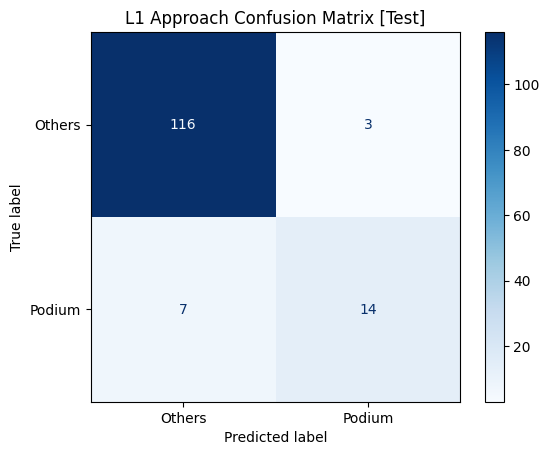

In [23]:
l1_test_preds = l1_pipeline.predict(X_test)
l1_test_cm = confusion_matrix(y_test, l1_test_preds)
print("Test Confusion Matrix for L1 Approach Pipeline")
print(l1_test_cm)
disp_l1_test_cm = ConfusionMatrixDisplay(confusion_matrix = l1_test_cm, display_labels = ['Others', 'Podium'])
disp_l1_test_cm.plot(cmap=plt.cm.Blues)
plt.title('L1 Approach Confusion Matrix [Test]')
plt.show()

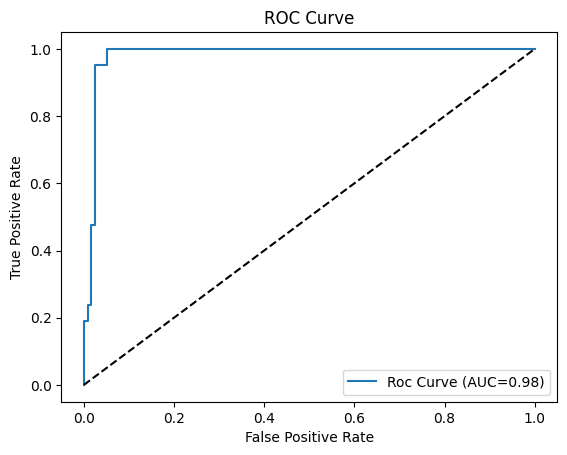

Roc Curve (AUC=0.98)


In [24]:
"""
ROC AUC Curves for the problem
"""
test_probs = l1_pipeline.predict_proba(X_test)[:, 1]
fpr, tpr, thresh = roc_curve(y_test, test_probs)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, label=f'Roc Curve (AUC={roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.title('ROC Curve')
plt.show()
print(f'Roc Curve (AUC={roc_auc:.2f})')

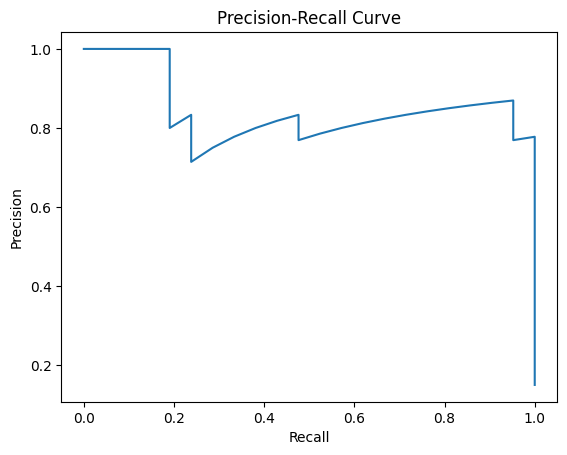

In [25]:
precision, recall, _ = precision_recall_curve(y_test, test_probs)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

#### ✅ Pre-quali model → “Who should podium”

In [26]:
test_probs = l1_pipeline.predict_proba(X_test)[:, 1]

pred_df = meta_test.copy()
pred_df["prob"] = test_probs

pred_df.sort_values(["Season", "Round", "prob"], ascending=[True, True, False])

,Season,Round,Driver,Team,Position,prob
609,2024,9,VER,Red Bull Racing,1.0,0.959980
325,2024,9,NOR,McLaren,2.0,0.764695
465,2024,9,RUS,Mercedes,3.0,0.687541
414,2024,9,PIA,McLaren,5.0,0.185316
189,2024,9,HAM,Mercedes,4.0,0.083402
...,...,...,...,...,...,...
599,2025,8,TSU,Red Bull Racing,17.0,0.000556
245,2025,8,HUL,Kick Sauber,16.0,0.000180
64,2025,8,ALO,Aston Martin,19.0,0.000089
73,2025,8,ANT,Mercedes,18.0,0.000030


In [27]:
print(df_model["Season"].unique())
print(df_model[df_model["Season"] == 2025]["Round"].unique())

[2024 2025]
[1 2 3 4 5 6 7 8 9]


In [28]:
aus_gp = df_model[(df_model["Season"] == 2025) & (df_model["Round"] == 9)].copy()

X_aus = aus_gp[feature_cols]
meta_aus = aus_gp[meta_cols]

aus_probs = l1_pipeline.predict_proba(X_aus)[:, 1]

aus_pred = meta_aus.copy()
aus_pred["podium_prob"] = aus_probs

aus_pred[['Driver', 'Team', 'Position', 'podium_prob']].sort_values("Position", ascending=True).head(10)








,Driver,Team,Position,podium_prob
438,PIA,McLaren,1.0,0.758117
349,NOR,McLaren,2.0,0.984523
294,LEC,Ferrari,3.0,0.371380
489,RUS,Mercedes,4.0,0.801409
246,HUL,Kick Sauber,5.0,0.020744
213,HAM,Ferrari,6.0,0.031890
180,HAD,Racing Bulls,7.0,0.007128
171,GAS,Alpine,8.0,0.017278
65,ALO,Aston Martin,9.0,0.005464
633,VER,Red Bull Racing,10.0,0.020197


In [11]:
def load_post_quali_data(model_df: pd.DataFrame, rounds_to_predict=None) -> pd.DataFrame:
    """
    Adds post-qualifying features to model_df by iterating over unique Season/Round pairs.

    Expected input columns in model_df:
        Season, Round, Driver, Team, Position, podium_finish, ...

    Added columns:
        Team_quali
        grid_position_proxy
        quali_fastest_lap_sec
        gap_to_pole_sec
        q1_sec
        q2_sec
        q3_sec
        made_q2
        made_q3
        teammate_fastest_lap_sec
        delta_to_teammate_sec
        raw_quali_rank
        grid_penalty_delta_proxy
        grid_penalty_applied_proxy
    """
    if model_df is None or not isinstance(model_df, pd.DataFrame):
        raise ValueError("model_df must be a valid pandas DataFrame.")

    base = model_df.copy()

    # For scoring one current round, pass rounds_to_predict=[(season, round_no)]
    if rounds_to_predict is None:
        race_keys = base[["Season", "Round"]].drop_duplicates()
    else:
        race_keys = pd.DataFrame(rounds_to_predict, columns=["Season", "Round"])

    all_quali_rows = []

    for _, rk in race_keys.iterrows():
        season = int(rk["Season"])
        round_no = int(rk["Round"])

        try:
            print(f"Loading qualifying for Season={season}, Round={round_no}")

            quali_sess = fastf1.get_session(season, round_no, "Q")
            quali_sess.load(laps=True, telemetry=False, weather=True, messages=True)

            qr = quali_sess.results.copy()

            if "Abbreviation" in qr.columns:
                qr = qr.rename(columns={"Abbreviation": "Driver"})
            if "TeamName" in qr.columns:
                qr = qr.rename(columns={"TeamName": "Team_quali"})

            if "Driver" not in qr.columns:
                raise ValueError("Qualifying results missing Driver column.")

            qr["grid_position_proxy"] = pd.to_numeric(qr["Position"], errors="coerce")

            # Q1/Q2/Q3 in seconds
            for c in ["Q1", "Q2", "Q3"]:
                if c in qr.columns:
                    qr[f"{c.lower()}_sec"] = pd.to_timedelta(qr[c], errors="coerce").dt.total_seconds()
                else:
                    qr[f"{c.lower()}_sec"] = np.nan

            qr["made_q2"] = qr["q2_sec"].notna().astype(int)
            qr["made_q3"] = qr["q3_sec"].notna().astype(int)

            # Fastest lap per driver in qualifying
            laps = quali_sess.laps.copy()
            if laps.empty:
                raise ValueError("No qualifying laps found.")

            laps["LapTime_sec"] = pd.to_timedelta(laps["LapTime"], errors="coerce").dt.total_seconds()
            if "IsAccurate" in laps.columns:
                laps = laps[laps["IsAccurate"].fillna(True)]

            laps = laps[laps["LapTime_sec"].notna()].copy()
            fastest = (
                laps.groupby("Driver", as_index=False)["LapTime_sec"]
                .min()
                .rename(columns={"LapTime_sec": "quali_fastest_lap_sec"})
            )

            fastest = fastest.merge(
                qr[["Driver", "Team_quali"]].drop_duplicates(),
                on="Driver",
                how="left"
            )

            pole_time = fastest["quali_fastest_lap_sec"].min()
            fastest["gap_to_pole_sec"] = fastest["quali_fastest_lap_sec"] - pole_time

            # raw fastest-lap rank
            fastest["raw_quali_rank"] = fastest["quali_fastest_lap_sec"].rank(method="min", ascending=True)

            # Teammate delta in quali
            fastest["teammate_fastest_lap_sec"] = np.nan
            fastest["delta_to_teammate_sec"] = np.nan

            for team, idx in fastest.groupby("Team_quali").groups.items():
                idx = list(idx)
                if len(idx) != 2:
                    continue

                a, b = idx
                lap_a = fastest.loc[a, "quali_fastest_lap_sec"]
                lap_b = fastest.loc[b, "quali_fastest_lap_sec"]

                fastest.loc[a, "teammate_fastest_lap_sec"] = lap_b
                fastest.loc[b, "teammate_fastest_lap_sec"] = lap_a
                fastest.loc[a, "delta_to_teammate_sec"] = lap_a - lap_b
                fastest.loc[b, "delta_to_teammate_sec"] = lap_b - lap_a

            quali_feat = qr[["Driver"]].drop_duplicates().merge(
                fastest[
                    [
                        "Driver",
                        "Team_quali",
                        "quali_fastest_lap_sec",
                        "gap_to_pole_sec",
                        "raw_quali_rank",
                        "teammate_fastest_lap_sec",
                        "delta_to_teammate_sec",
                    ]
                ],
                on="Driver",
                how="left"
            ).merge(
                qr[
                    [
                        "Driver",
                        "grid_position_proxy",
                        "q1_sec",
                        "q2_sec",
                        "q3_sec",
                        "made_q2",
                        "made_q3",
                    ]
                ],
                on="Driver",
                how="left"
            )

            # Grid penalty proxy:
            # difference between raw lap rank and official qualifying position
            quali_feat["grid_penalty_delta_proxy"] = (
                quali_feat["raw_quali_rank"] - quali_feat["grid_position_proxy"]
            )
            quali_feat["grid_penalty_applied_proxy"] = (
                quali_feat["grid_penalty_delta_proxy"].abs() > 0
            ).astype(int)

            quali_feat["Season"] = season
            quali_feat["Round"] = round_no

            all_quali_rows.append(quali_feat)

        except Exception as e:
            print(f"Skipping Season={season}, Round={round_no} -> {e}")

    if not all_quali_rows:
        return base

    quali_all = pd.concat(all_quali_rows, ignore_index=True)

    # Merge back into the base dataframe
    out = base.merge(
        quali_all,
        on=["Season", "Round", "Driver"],
        how="left",
        suffixes=("", "_quali")
    )

    return out

In [ ]:
post_quali_df = load_post_quali_data(df_model)

In [13]:
def progress_save_utility(df: pd.DataFrame, fname: str="default", save: bool=False, load: bool=True):
    save_dir = Path('../data/saves')
    file_path = save_dir / f"{fname}"
    
    if save:
        save_dir.mkdir(parents=True, exist_ok=True)
        
        if df is not None and not df.empty:
            df.to_csv(file_path, index=False)
            print(f"DataFrame saved to {file_path}")
        else:
            print("No DataFrame provided to save.")
        return None

    if load and not save:                
        if file_path.exists():
            print(f"Loading DataFrame from {file_path}")
            return pd.read_csv(file_path)
        else:
            print(f"File {file_path} does not exist.")
            return None

#### ✅ Post-quali model → “Who will be on podium”

In [130]:
post_quali_df = progress_save_utility(pd.DataFrame, "post_quali_df_latest.csv", False, True)
post_quali_df.head(3)

Loading DataFrame from ..\data\saves\post_quali_df_latest.csv


,Season,Round,Driver,Team,Position,teammate_points,teammate_podium,teammate_finish_delta,teammate_points_delta,avg_teammate_finish_delta_last_n,avg_teammate_points_delta_last_n,constructor_standing_prev,avg_team_finish,reliability_to_date_prev,pace_rank_prev,is_sprint_weekend,constructor_points_prev,avg_finish_to_date_prev,avg_points_to_date_prev,dnf_rate_to_date_prev,avg_team_finish_last_15,team_points_last_15,team_dnf_rate_last_15,practice_best_lap_mean,practice_avg_lap_mean,practice_long_run_pace_mean,practice_session_rank_mean,podium_finish,quali_fastest_lap_sec,gap_to_pole_sec,raw_quali_rank,teammate_fastest_lap_sec,delta_to_teammate_sec,grid_position_proxy,q1_sec,q2_sec,q3_sec,made_q2,made_q3,grid_penalty_delta_proxy,grid_penalty_applied_proxy
0,2024,1,ALB,Williams,15.0,0.000000,0.000000,5.0,0.0,0.055151,0.034941,1.0,17.5,0.769488,5.456311,0.0,0.0,10.45391,10.196067,0.230512,0.0,0.0,0.231385,92.293667,110.033141,110.264231,13.000000,0.0,90.221,1.056,13.0,90.770000,-0.549000,13.0,90.397,90.221,0.0,1,0,0.0,0
1,2024,2,ALB,Williams,11.0,0.000000,0.000000,3.0,0.0,5.000000,0.000000,6.0,12.5,1.000000,9.000000,0.0,0.0,17.50000,0.000000,0.000000,17.5,0.0,0.000000,90.114667,106.166077,103.748050,13.666667,0.0,88.980,1.508,12.0,89.526000,-0.546000,12.0,89.107,88.980,0.0,1,0,0.0,0
2,2024,3,ALB,Williams,11.0,5.106707,0.150915,0.0,0.0,4.000000,0.000000,7.0,11.0,1.000000,8.000000,0.0,0.0,15.00000,0.000000,0.000000,15.0,0.0,0.000000,78.601000,95.697538,93.430384,12.500000,0.0,77.130,1.215,12.0,83.950781,1.323693,12.0,77.130,77.167,0.0,1,0,0.0,0


In [ ]:
post_quali_df['q1_sec'].fillna(0, inplace=True)
post_quali_df['q2_sec'].fillna(0, inplace=True)
post_quali_df['q3_sec'].fillna(0, inplace=True)
post_quali_df['gap_to_pole_sec'].fillna(post_quali_df['gap_to_pole_sec'].max(), inplace=True)
post_quali_df['quali_fastest_lap_sec'].fillna(post_quali_df['quali_fastest_lap_sec'].mean(), inplace=True)
post_quali_df['raw_quali_rank'].fillna(post_quali_df['raw_quali_rank'].mean(), inplace=True)
post_quali_df['teammate_fastest_lap_sec'].fillna(post_quali_df['teammate_fastest_lap_sec'].mean(), inplace=True)
post_quali_df['delta_to_teammate_sec'].fillna(post_quali_df['delta_to_teammate_sec'].std(), inplace=True)
post_quali_df['grid_penalty_delta_proxy'].fillna(post_quali_df['grid_penalty_delta_proxy'].mean(), inplace=True)
post_quali_df.drop(columns='Team_quali', inplace=True)


In [48]:
post_quali_formula = """
podium_finish ~
teammate_points +
teammate_podium +
teammate_finish_delta +
avg_teammate_points_delta_last_n +
constructor_standing_prev +
avg_team_finish_last_15 +
team_dnf_rate_last_15 +
practice_best_lap_mean +
quali_fastest_lap_sec +
gap_to_pole_sec +
raw_quali_rank +
teammate_fastest_lap_sec +
delta_to_teammate_sec +
grid_position_proxy +
q1_sec +
q2_sec +
q3_sec +
made_q2 +
made_q3 +
grid_penalty_delta_proxy +
grid_penalty_applied_proxy
"""

post_quali_model_sm = sm.logit(formula=post_quali_formula, data=post_quali_df).fit()
print(post_quali_model_sm.summary())

         Current function value: 0.156827
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:          podium_finish   No. Observations:                  958
Model:                          Logit   Df Residuals:                      936
Method:                           MLE   Df Model:                           21
Date:                Mon, 30 Mar 2026   Pseudo R-squ.:                  0.5897
Time:                        18:48:49   Log-Likelihood:                -150.24
converged:                      False   LL-Null:                       -366.19
Covariance Type:            nonrobust   LLR p-value:                 2.267e-78
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                           -3.2132      1.661     -1.934      0.053      -6.469       0.043

C:\Users\athar\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<h4>
    <strong>
    Now Based on the above conclusion we can remove these:
    </strong>
</h4>
    <ul>
    <li>quali_fastest_lap_sec</li>
    <li>raw_quali_rank</li>
    <li>q1_sec</li>
    <li>q2_sec</li>
    <li>q3_sec</li>
    <li>made_q2</li>
    <li>grid_penalty_delta_proxy</li>
    <li>grid_penalty_applied_proxy</li>
    </ul>


In [49]:
new_post_quali_formula="""
podium_finish ~
teammate_points +
teammate_podium +
teammate_finish_delta +
avg_teammate_points_delta_last_n +
constructor_standing_prev +
avg_team_finish_last_15 +
team_dnf_rate_last_15 +
practice_best_lap_mean +
quali_fastest_lap_sec +
gap_to_pole_sec +
raw_quali_rank +
teammate_fastest_lap_sec +
delta_to_teammate_sec +
grid_position_proxy +
made_q3
"""

final_post_quali_model_sm = sm.logit(formula=new_post_quali_formula, data=post_quali_df).fit()
print(final_post_quali_model_sm.summary())

Optimization terminated successfully.
         Current function value: 0.157530
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:          podium_finish   No. Observations:                  958
Model:                          Logit   Df Residuals:                      942
Method:                           MLE   Df Model:                           15
Date:                Mon, 30 Mar 2026   Pseudo R-squ.:                  0.5879
Time:                        18:48:52   Log-Likelihood:                -150.91
converged:                       True   LL-Null:                       -366.19
Covariance Type:            nonrobust   LLR p-value:                 2.583e-82
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                           -2.8651      1.089     -2.63

In [ ]:
driver_team_map = (
    post_quali_df.groupby("Driver")["Team"]
    .agg(lambda x: x.mode()[0])
    .to_dict()
)
driver_team_map.pop('0')


In [141]:
driver_team_map['LIN'] = 'RB'
driver_team_map

{'ALB': 'Williams',
 'ALO': 'Aston Martin',
 'ANT': 'Mercedes',
 'BEA': 'Haas F1 Team',
 'BOR': 'Kick Sauber',
 'BOT': 'Kick Sauber',
 'COL': 'Williams',
 'DOO': 'Alpine',
 'GAS': 'Alpine',
 'HAD': 'Racing Bulls',
 'HAM': 'Mercedes',
 'HUL': 'Haas F1 Team',
 'LAW': 'Racing Bulls',
 'LEC': 'Ferrari',
 'MAG': 'Haas F1 Team',
 'NOR': 'McLaren',
 'OCO': 'Alpine',
 'PER': 'Red Bull Racing',
 'PIA': 'McLaren',
 'RIC': 'RB',
 'RUS': 'Mercedes',
 'SAI': 'Ferrari',
 'SAR': 'Williams',
 'STR': 'Aston Martin',
 'TSU': 'RB',
 'VER': 'Red Bull Racing',
 'ZHO': 'Kick Sauber',
 'LIN': 'RB'}

In [111]:
def append_new_race(post_quali_df: pd.DataFrame, season: int, round_no: int) -> pd.DataFrame:
    """
    Append a new race (post-quali) to the existing dataset.

    Assumes:
    - historical data already exists in post_quali_df
    - features are computed using only past data
    """

    print(f"Building features for Season={season}, Round={round_no}")

    quali = fastf1.get_session(season, round_no, "Q")
    quali.load()

    drivers = quali.results["Abbreviation"].values
    teams = quali.results["TeamName"].values

    base_df = pd.DataFrame({
        "Season": season,
        "Round": round_no,
        "Driver": drivers,
        "Team": teams,
    })

    history = post_quali_df.copy()

    driver_features = []
    for d in drivers:
        d_hist = history[history["Driver"] == d].sort_values(["Season", "Round"])

        last_n = d_hist.tail(15)

        driver_features.append({
            "Driver": d,
            "teammate_points": last_n["teammate_points"].mean(),
            "teammate_podium": last_n["teammate_podium"].mean(),
            "teammate_finish_delta": last_n["teammate_finish_delta"].mean(),
            "teammate_points_delta": last_n["teammate_points_delta"].mean(),
            "avg_teammate_finish_delta_last_n": last_n["avg_teammate_finish_delta_last_n"].mean(),
            "avg_teammate_points_delta_last_n": last_n["avg_teammate_points_delta_last_n"].mean(),
        })

    driver_feat_df = pd.DataFrame(driver_features)

    team_features = []

    for t in base_df["Team"].unique():
        t_hist = history[history["Team"] == t].sort_values(["Season", "Round"])
        last_n = t_hist.tail(15)

        team_features.append({
            "Team": t,
            "constructor_standing_prev": last_n["constructor_standing_prev"].iloc[-1] if not last_n.empty else np.nan,
            "avg_team_finish_last_15": last_n["avg_team_finish_last_15"].mean(),
            "team_points_last_15": last_n["team_points_last_15"].mean(),
            "team_dnf_rate_last_15": last_n["team_dnf_rate_last_15"].mean(),
        })

    team_feat_df = pd.DataFrame(team_features)


    practice_df = load_practice_data(
        seasons=[season],
        n_races=15
    )

    practice_df = practice_df[
        (practice_df["Season"] == season) &
        (practice_df["Round"] == round_no)
    ]

    quali_df = load_post_quali_data(
        base_df
        # rounds_to_predict=round_no
    )


    new_race_df = base_df.merge(driver_feat_df, on="Driver", how="left")
    new_race_df = new_race_df.merge(team_feat_df, on="Team", how="left")
    new_race_df = new_race_df.merge(practice_df, on=["Season", "Round", "Driver"], how="left")
    new_race_df = new_race_df.merge(quali_df, on=["Season", "Round", "Driver"], how="left")

    for col in post_quali_df.columns:
        if col not in new_race_df.columns:
            new_race_df[col] = np.nan

    new_race_df = new_race_df[post_quali_df.columns]

    new_race_df["podium_finish"] = np.nan


    updated_df = pd.concat([post_quali_df, new_race_df], ignore_index=True)

    return updated_df

In [ ]:
post_quali_df = append_new_race(post_quali_df, 2026, 1)

In [191]:
post_quali_df.isnull().sum(axis=0)

Season                              0
Round                               0
Driver                              0
Team                                0
Position                            0
teammate_points                     0
teammate_podium                     0
teammate_finish_delta               0
teammate_points_delta               0
avg_teammate_finish_delta_last_n    0
avg_teammate_points_delta_last_n    0
constructor_standing_prev           0
avg_team_finish                     0
reliability_to_date_prev            0
pace_rank_prev                      0
is_sprint_weekend                   0
constructor_points_prev             0
avg_finish_to_date_prev             0
avg_points_to_date_prev             0
dnf_rate_to_date_prev               0
avg_team_finish_last_15             0
team_points_last_15                 0
team_dnf_rate_last_15               0
practice_best_lap_mean              0
practice_avg_lap_mean               0
practice_long_run_pace_mean         0
practice_ses

In [206]:
# post_quali_df = post_quali_df[post_quali_df["Season"] == 2025].copy()
# post_quali_df.drop(post_quali_df[post_quali_df['Driver'] == 'PER'].index, inplace=True)
# post_quali_df.drop(post_quali_df[post_quali_df['Driver'] == 'TSU'].index, inplace=True)

post_quali_df.loc[post_quali_df['Driver'] == 'HAM', 'Team'] = 'Ferrari'
post_quali_df.loc[post_quali_df['Driver'] == 'SAI', 'Team'] = 'Williams'
# post_quali_df.drop(post_quali_df[post_quali_df['Driver'] == '0'].index, inplace=True)
# audi_cons = post_quali_df.loc[post_quali_df['Team'] == 'Kick Sauber']['constructor_standing_prev'].mean()
# post_quali_df.loc[post_quali_df['constructor_standing_prev'].isnull()] = audi_cons
# post_quali_df.dropna(subset=['Position'], inplace=True, ignore_index=True)
# post_quali_df.loc[post_quali_df['teammate_fastest_lap_sec'].isna()] = 0

In [153]:
drivers = post_quali_df["Driver"].unique()
null_fields = ['avg_team_finish', 'reliability_to_date_prev', 'pace_rank_prev', 'constructor_points_prev',
               'avg_finish_to_date_prev', 'avg_points_to_date_prev', 'dnf_rate_to_date_prev', 'podium_finish',
               'q2_sec', 'q3_sec']
for d in drivers:
    post_quali_df.loc[
        (post_quali_df["Driver"] == d) &
        (post_quali_df["Season"] == 2026) &
        (post_quali_df["Round"] == 1) & 
        (post_quali_df["Team"].isna()), 
        "Team"] = driver_team_map[d]
for i in range(1, 2):
    for d in drivers:
        d_mean = post_quali_df[post_quali_df["Driver"]==d]["Position"].mean()
        post_quali_df.loc[
        (post_quali_df["Driver"] == d) &
        (post_quali_df["Season"] == 2026) &
        (post_quali_df["Round"] == i) & 
        (post_quali_df["Position"].isna()), 
        "Position"] = d_mean
        post_quali_df.loc[
        (post_quali_df["Driver"] == d) &
        (post_quali_df["Season"] == 2026) &
        (post_quali_df["Round"] == i) & 
        (post_quali_df["Team"].isna()), 
        "Team"] = driver_team_map[d]
    
        for nf in null_fields:
            if nf == 'q2_sec' or nf == 'q3_sec':
                post_quali_df.loc[
                (post_quali_df["Driver"] == d) &
                (post_quali_df["Season"] == 2026) &
                (post_quali_df["Round"] == i) & 
                (post_quali_df[nf].isna()),
                nf] = 0
            else:
                nf_mean = post_quali_df[post_quali_df["Driver"] == d][nf].mean()
                post_quali_df.loc[
                (post_quali_df["Driver"] == d) &
                (post_quali_df["Season"] == 2026) &
                (post_quali_df["Round"] == i) & 
                (post_quali_df[nf].isna()),
                    nf] = nf_mean
        
    

In [207]:
post_quali_feature_cols=[
    'teammate_points',
    'teammate_podium',
    'teammate_finish_delta',
    'avg_teammate_points_delta_last_n',
    'constructor_standing_prev',
    'avg_team_finish_last_15',
    'team_dnf_rate_last_15',
    'practice_best_lap_mean',
    'quali_fastest_lap_sec',
    'gap_to_pole_sec',
    'raw_quali_rank',
    'teammate_fastest_lap_sec',
    'delta_to_teammate_sec',
    'grid_position_proxy',
    'made_q3'
]

post_quali_meta_cols = ['Season', 'Round', 'Driver', 'Team', 'Position']

post_quali_X = post_quali_df[post_quali_feature_cols].copy()
post_quali_y = post_quali_df['podium_finish'].copy()
pq_meta = post_quali_df[post_quali_meta_cols].copy()

In [208]:
gss = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)

post_quali_groups = post_quali_df["Round"] + post_quali_df["Season"] * 100

post_quali_train_idx, post_quali_test_idx = next(gss.split(post_quali_X, post_quali_y, groups=post_quali_groups))

post_quali_X_train, post_quali_X_test = post_quali_X.iloc[post_quali_train_idx], post_quali_X.iloc[post_quali_test_idx]
post_quali_y_train, post_quali_y_test = post_quali_y.iloc[post_quali_train_idx], post_quali_y.iloc[post_quali_test_idx]
post_quali_meta_train, post_quali_meta_test = pq_meta.iloc[post_quali_train_idx], pq_meta.iloc[post_quali_test_idx]


post_quali_y_train = (post_quali_y_train > 0.5).astype(int)
post_quali_y_test = (post_quali_y_test > 0.5).astype(int)

In [209]:
print(post_quali_y_train.dtype)
print(post_quali_y_train.head())
print(post_quali_y_train.unique()[:10])
print(post_quali_y_test.dtype)
print(post_quali_y_test.head())
print(post_quali_y_test.unique()[:10])

int32
0    0
2    0
3    0
4    0
5    0
Name: podium_finish, dtype: int32
[0 1]
int32
1     0
10    0
11    0
15    0
22    0
Name: podium_finish, dtype: int32
[0 1]


In [210]:
post_quali_l1_results = l1_log_reg_model(post_quali_X_train, post_quali_y_train)
post_quali_best_pair_l1 = max(post_quali_l1_results, key=post_quali_l1_results.get)
post_quali_best_score_l1 = post_quali_l1_results[post_quali_best_pair_l1]
post_quali_c_best = post_quali_best_pair_l1[1]
post_quali_l_best = post_quali_best_pair_l1[0]
print("Best (l, C):", post_quali_best_pair_l1)
print("Best CV Accuracy:", post_quali_best_score_l1)
print("Best C: ", post_quali_c_best)
print("Best L: ", post_quali_l_best)

Best (l, C): (1, 0.1)
Best CV Accuracy: 0.9285714285714286
Best C:  0.1
Best L:  1


Confusion Matrix for Post Quali Pipeline[Train]
[[583  16]
 [ 30  71]]


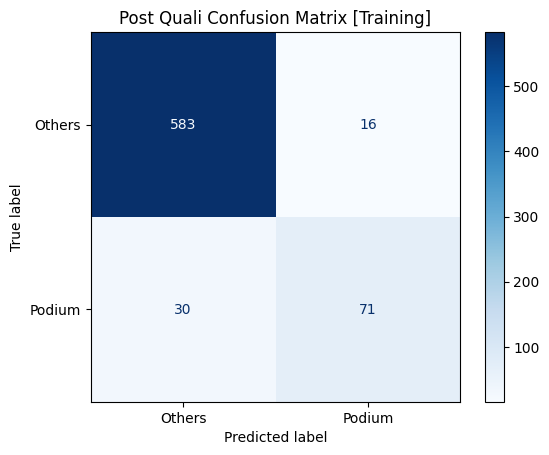

In [211]:
post_quali_l1_pipeline = Pipeline([
                ("scaler", StandardScaler()),
                ("model", LogisticRegression(
                    penalty="l1",
                    solver="liblinear",
                    C = post_quali_c_best,
                    max_iter=1000
                ))
            ])
post_quali_l1_pipeline.fit(post_quali_X_train, post_quali_y_train)
post_quali_l1_train_preds = post_quali_l1_pipeline.predict(post_quali_X_train)
post_quali_l1_cm = confusion_matrix(post_quali_y_train, post_quali_l1_train_preds)
print("Confusion Matrix for Post Quali Pipeline[Train]")
print(post_quali_l1_cm)
post_quali_disp_l1_cm = ConfusionMatrixDisplay(confusion_matrix = post_quali_l1_cm, display_labels = ['Others', 'Podium'])
post_quali_disp_l1_cm.plot(cmap=plt.cm.Blues)
plt.title('Post Quali Confusion Matrix [Training]')
plt.show()

Test Confusion Matrix for Post Quali Pipeline
[[160   9]
 [ 11  18]]


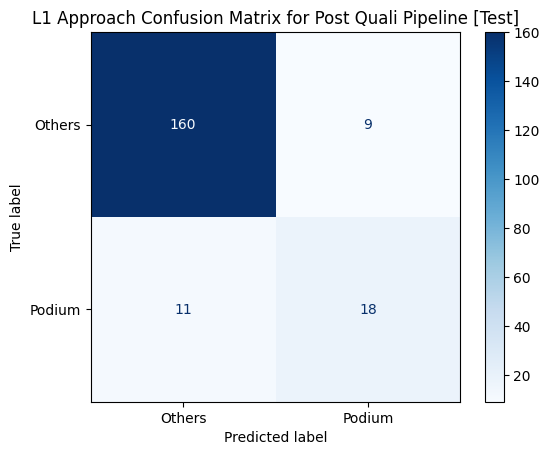

In [212]:
post_quali_l1_test_preds = post_quali_l1_pipeline.predict(post_quali_X_test)
post_quali_l1_test_cm = confusion_matrix(post_quali_y_test, post_quali_l1_test_preds)
print("Test Confusion Matrix for Post Quali Pipeline")
print(post_quali_l1_test_cm)
post_quali_disp_l1_test_cm = ConfusionMatrixDisplay(confusion_matrix = post_quali_l1_test_cm, display_labels = ['Others', 'Podium'])
post_quali_disp_l1_test_cm.plot(cmap=plt.cm.Blues)
plt.title('L1 Approach Confusion Matrix for Post Quali Pipeline [Test]')
plt.show()

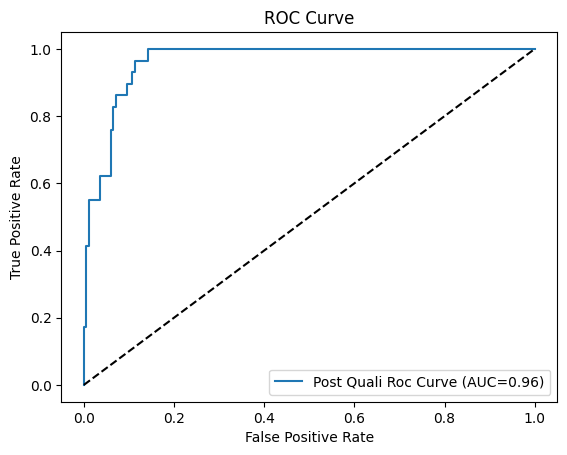

Post Quali Roc Curve (AUC=0.96)


In [213]:
"""
ROC AUC Curves for Post Quali Model
"""
post_quali_test_probs = post_quali_l1_pipeline.predict_proba(post_quali_X_test)[:, 1]
post_quali_fpr, post_quali_tpr, post_quali_thresh = roc_curve(post_quali_y_test, post_quali_test_probs)
post_quali_roc_auc = auc(post_quali_fpr, post_quali_tpr)
plt.figure()
plt.plot(post_quali_fpr, post_quali_tpr, label=f'Post Quali Roc Curve (AUC={post_quali_roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.title('ROC Curve')
plt.show()
print(f'Post Quali Roc Curve (AUC={post_quali_roc_auc:.2f})')

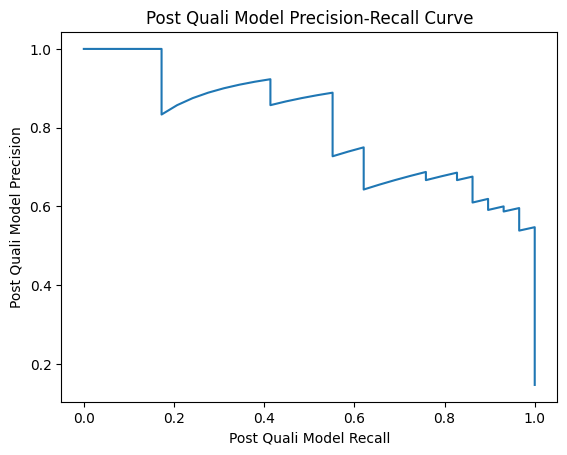

In [214]:
post_quali_precision, post_quali_recall, _ = precision_recall_curve(post_quali_y_test, post_quali_test_probs)

plt.plot(post_quali_recall, post_quali_precision)
plt.xlabel("Post Quali Model Recall")
plt.ylabel("Post Quali Model Precision")
plt.title("Post Quali Model Precision-Recall Curve")
plt.show()

In [216]:
post_quali_pred_df = post_quali_meta_test.copy()
post_quali_pred_df["prob"] = post_quali_test_probs
post_quali_pred_df.sort_values(["Season", "Round", "Position", "prob"], ascending=[False, False, True, True]).head(10)

,Season,Round,Driver,Team,Position,prob
885,2025.0,21.0,VER,Red Bull Racing,3.666667,0.245457
871,2025.0,21.0,NOR,McLaren,3.696970,0.719995
874,2025.0,21.0,PIA,McLaren,4.424242,0.461472
873,2025.0,21.0,LEC,Ferrari,4.969697,0.282225
876,2025.0,21.0,RUS,Mercedes,6.212121,0.281774
882,2025.0,21.0,HAM,Ferrari,7.212121,0.060745
884,2025.0,21.0,SAI,Williams,7.531250,0.012406
872,2025.0,21.0,ANT,Mercedes,10.444444,0.057308
875,2025.0,21.0,HAD,Racing Bulls,10.555556,0.064397
880,2025.0,21.0,ALO,Aston Martin,11.181818,0.027305


In [75]:
print(post_quali_df["Season"].unique())
print(post_quali_df[post_quali_df["Season"] == 2025]["Round"].unique())

[2025]
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24]


In [242]:
post_quali_aus_gp = post_quali_df[(post_quali_df["Season"] == 2026) & (post_quali_df["Round"] == 1)].copy()

post_quali_X_aus = post_quali_aus_gp[post_quali_feature_cols]
post_quali_meta_aus = post_quali_aus_gp[post_quali_meta_cols]

post_quali_aus_probs = post_quali_l1_pipeline.predict_proba(post_quali_X_aus)[:, 1]

post_quali_aus_pred = post_quali_meta_aus.copy()
post_quali_aus_pred["podium_prob"] = post_quali_aus_probs

post_quali_aus_pred[['Driver', 'Team', 'podium_prob', 'Position']].sort_values("podium_prob", ascending=False).head(10)

,Driver,Team,podium_prob,Position
954,NOR,McLaren,0.549025,3.696970
953,PIA,McLaren,0.432990,4.424242
952,LEC,Ferrari,0.237834,4.969697
949,RUS,Mercedes,0.418614,6.212121
955,HAM,Ferrari,0.087360,7.212121
950,ANT,Mercedes,0.067852,10.444444
959,BEA,Haas F1 Team,0.015541,12.416667
961,GAS,Alpine,0.022930,13.151515
960,OCO,Alpine,0.015970,13.375000
956,LAW,Racing Bulls,0.014660,13.533333


In [240]:
# res = res[res['Team'] != 'McLaren']
res

,Driver,Team,podium_prob,Position
954,NOR,McLaren,0.549025,3.696970
953,PIA,McLaren,0.432990,4.424242
949,RUS,Mercedes,0.418614,6.212121
952,LEC,Ferrari,0.237834,4.969697
955,HAM,Ferrari,0.087360,7.212121
950,ANT,Mercedes,0.067852,10.444444
961,GAS,Alpine,0.022930,13.151515
960,OCO,Alpine,0.015970,13.375000
959,BEA,Haas F1 Team,0.015541,12.416667
956,LAW,Racing Bulls,0.014660,13.533333


In [180]:
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)

required_objects = {
    "post_quali_df": "your full modeling dataframe",
    "post_quali_l1_pipeline": "your trained sklearn pipeline",
    "post_quali_feature_cols": "the exact feature list used for training",
}

for name, desc in required_objects.items():
    if name not in globals():
        print(f"Warning: {name} is not defined yet ({desc}).")

In [181]:
def get_available_races(df: pd.DataFrame) -> pd.DataFrame:
    """Return sorted unique race keys."""
    return (
        df[["Season", "Round"]]
        .drop_duplicates()
        .sort_values(["Season", "Round"])
        .reset_index(drop=True)
    )


def get_race_slice(df: pd.DataFrame, season: int, round_no: int) -> pd.DataFrame:
    """Filter one race from the full dataframe."""
    race_df = df[(df["Season"] == season) & (df["Round"] == round_no)].copy()
    return race_df


def add_predictions(race_df: pd.DataFrame, model, feature_cols: list) -> pd.DataFrame:
    """
    Add podium probability predictions to a race dataframe.
    Assumes race_df already contains the feature columns.
    """
    X = race_df[feature_cols].copy()
    probs = model.predict_proba(X)[:, 1]
    out = race_df.copy()
    out["podium_prob"] = probs
    out = out.sort_values("podium_prob", ascending=False).reset_index(drop=True)
    out["pred_rank"] = np.arange(1, len(out) + 1)
    return out


def top3_table(df_pred: pd.DataFrame) -> pd.DataFrame:
    """Return a compact top-3 table."""
    cols = [c for c in ["Season", "Round", "Driver", "Team", "podium_prob", "pred_rank"] if c in df_pred.columns]
    return df_pred[cols].head(3).copy()

In [182]:
race_keys = get_available_races(post_quali_df)

print("Available races:")
display(race_keys.head(10))

season0 = int(race_keys.iloc[-1]["Season"])
round0 = int(race_keys.iloc[-1]["Round"])

race_df = get_race_slice(post_quali_df, season0, round0)
print("Rows in selected race:", len(race_df))

pred_df = add_predictions(race_df, post_quali_l1_pipeline, post_quali_feature_cols)
display(top3_table(pred_df))

Available races:


,Season,Round
0,0.000,0.000
1,8.575,8.575
2,2024.000,1.000
3,2024.000,2.000
4,2024.000,3.000
5,2024.000,4.000
6,2024.000,5.000
7,2024.000,6.000
8,2024.000,7.000
9,2024.000,8.000


Rows in selected race: 11


,Season,Round,Driver,Team,podium_prob,pred_rank
0,2026.0,1.0,NOR,McLaren,0.540474,1
1,2026.0,1.0,RUS,Mercedes,0.419946,2
2,2026.0,1.0,PIA,McLaren,0.413849,3


In [183]:
def plot_podium_probabilities(df_pred: pd.DataFrame):
    fig = px.bar(
        df_pred.sort_values("podium_prob", ascending=True),
        x="podium_prob",
        y="Driver",
        orientation="h",
        color="Team",
        title="Podium Probability by Driver"
    )
    fig.update_layout(height=600)
    return fig


def display_top3(df_pred: pd.DataFrame):
    top3 = df_pred.head(3).copy()
    top3["podium_prob"] = (top3["podium_prob"] * 100).round(1).astype(str) + "%"
    
    return HTML(top3[["Driver", "Team", "podium_prob"]].to_html(index=False))


def display_actual_vs_pred(df_pred: pd.DataFrame):
    if "Position" not in df_pred.columns:
        return HTML("<b>No actual results available</b>")

    actual = df_pred.sort_values("Position").head(3)["Driver"].tolist()
    predicted = df_pred.head(3)["Driver"].tolist()

    html = f"""
    <b>Predicted Top 3:</b> {predicted} <br>
    <b>Actual Top 3:</b> {actual}
    """
    return HTML(html)

In [184]:
def run_dashboard(_):
    with output:
        clear_output()

        season = season_dd.value
        round_no = round_dd.value

        print(f"Running prediction for Season {season}, Round {round_no}")

        race_df = get_race_slice(post_quali_df, season, round_no)

        if race_df.empty:
            print("No data for this race.")
            return

        df_pred = add_predictions(race_df, post_quali_l1_pipeline, post_quali_feature_cols)

        # --- Top 3 ---
        display(HTML("<h3>🏆 Predicted Podium</h3>"))
        display(display_top3(df_pred))

        # --- Bar chart ---
        fig = plot_podium_probabilities(df_pred)
        fig.show()

        # --- Actual vs Predicted ---
        display(HTML("<h3>📊 Actual vs Predicted</h3>"))
        display(display_actual_vs_pred(df_pred))

In [219]:
refresh_btn.on_click(run_dashboard)

In [186]:
race_keys = get_available_races(post_quali_df)

seasons = sorted(race_keys["Season"].unique())
rounds_by_season = {
    s: sorted(race_keys[race_keys["Season"] == s]["Round"].unique())
    for s in seasons
}

# Widgets
season_dd = widgets.Dropdown(
    options=seasons,
    value=seasons[-1],
    description="Season:"
)

round_dd = widgets.Dropdown(
    options=rounds_by_season[season_dd.value],
    description="Round:"
)

stage_dd = widgets.ToggleButtons(
    options=["Post-Quali"],  # later add Pre-Quali
    description="Stage:"
)

refresh_btn = widgets.Button(
    description="Run Prediction",
    button_style="success"
)

output = widgets.Output()


def update_rounds(change):
    round_dd.options = rounds_by_season[change["new"]]
    round_dd.value = round_dd.options[0]

season_dd.observe(update_rounds, names="value")

controls = widgets.HBox([season_dd, round_dd, stage_dd, refresh_btn])
display(controls, output)

Output()